<a href="https://colab.research.google.com/github/MDuke235/onnxruntime_test/blob/main/pv_et_xgb_rf_xai_blocked_kfold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XAI for ET + XGB + RF PV Forecasting

Notebook này chạy XAI cho ensemble tốt nhất **ET + XGB + RF** trên ba horizon: **1h, 2h, 3h**.

Thiết kế chính:
- Nếu đã có model artifact trong Google Drive thì notebook sẽ load lại.
- Nếu chưa có, notebook sẽ retrain ET, XGB, RF theo từng blocked seasonal fold rồi lưu lại bằng `joblib`.
- XAI được tính trên held-out test folds, ưu tiên daylight samples để tránh giải thích các điểm ban đêm bị hard-set về 0 bởi night rule.
- Kết quả gồm: CV metrics, model-based importance, permutation importance, SHAP global, SHAP theo nhóm feature, residual correlation và local SHAP cho điểm sai lớn.

In [ ]:
# ============================================================
# 0. Install and import packages
# ============================================================

!pip -q install shap xgboost joblib

import os
import math
import time
import json
import inspect
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.base import clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet, HuberRegressor
import joblib

warnings.filterwarnings("ignore")

try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP version:", shap.__version__)
except Exception as e:
    SHAP_AVAILABLE = False
    print("SHAP is not available:", repr(e))

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SHAP version: 0.52.0


In [ ]:
# ============================================================
# 1. Mount Drive and set paths
# ============================================================

drive.mount("/content/drive")

DATA_PATH = Path("/content/drive/MyDrive/data4dav/filtered1.csv")

OUTPUT_DIR = Path("/content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

XAI_DIR = OUTPUT_DIR / "xai_et_xgb_rf"
XAI_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR = XAI_DIR / "saved_fold_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = XAI_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = XAI_DIR / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("XAI_DIR:", XAI_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("FIG_DIR:", FIG_DIR)

Mounted at /content/drive
DATA_PATH: /content/drive/MyDrive/data4dav/filtered1.csv
OUTPUT_DIR: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results
XAI_DIR: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf
MODEL_DIR: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/saved_fold_models
FIG_DIR: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures


In [ ]:
# ============================================================
# 2. Check whether previous trained model artifacts already exist
# ============================================================

def find_existing_model_artifacts(base_dir):
    patterns = ["*.joblib", "*.pkl", "*.pickle", "*.model", "*.json"]
    found = []
    base_dir = Path(base_dir)
    if base_dir.exists():
        for pat in patterns:
            found.extend(base_dir.rglob(pat))
    return sorted(found)

existing_model_artifacts = find_existing_model_artifacts(OUTPUT_DIR)

print(f"Found {len(existing_model_artifacts)} possible model artifact files under:")
print(OUTPUT_DIR)

for p in existing_model_artifacts[:30]:
    print("-", p)

if len(existing_model_artifacts) == 0:
    print("\nNo saved model artifact was found in the previous result folder.")
    print("This notebook will retrain ET + XGB + RF fold models and save them for future XAI runs.")
else:
    print("\nSome model-like files were found. The notebook will still use MODEL_DIR below for ET+XGB+RF artifacts.")

Found 0 possible model artifact files under:
/content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results

No saved model artifact was found in the previous result folder.
This notebook will retrain ET + XGB + RF fold models and save them for future XAI runs.


In [ ]:
# ============================================================
# 3. Global configuration
# ============================================================

FREQ_MINUTES = 15
STEPS_PER_HOUR = 4

HORIZONS = {
    "1h_ahead": 4,
    "2h_ahead": 8,
    "3h_ahead": 12,
}

HORIZON_LABELS = {
    "1h_ahead": "1h",
    "2h_ahead": "2h",
    "3h_ahead": "3h",
}

RUN_MODES = ["15min_issue"]
MEASUREMENT_LATENCY_STEPS = 0

CV_MONTHS_PER_BLOCK = 2
CV_N_FOLDS = 6
CV_VALIDATION_OFFSET = 1
CV_PURGE_AFTER_HELDOUT = True

SAFE_MAPE_FLOOR_FRAC = 0.05

BEST_ENSEMBLE_NAME = "ET+XGB+RF"
BEST_ENSEMBLE_MEMBERS = ["ExtraTrees", "XGBoost", "RandomForest"]

# XAI runtime controls.
# Increase sample sizes if you have enough time.
XAI_DAYLIGHT_ONLY = True
SHAP_SAMPLE_PER_FOLD = 350
PERM_SAMPLE_PER_FOLD = 700
PERM_REPEATS = 5

print("Best ensemble:", BEST_ENSEMBLE_NAME, BEST_ENSEMBLE_MEMBERS)
print("SHAP_SAMPLE_PER_FOLD:", SHAP_SAMPLE_PER_FOLD)
print("PERM_SAMPLE_PER_FOLD:", PERM_SAMPLE_PER_FOLD)

Best ensemble: ET+XGB+RF ['ExtraTrees', 'XGBoost', 'RandomForest']
SHAP_SAMPLE_PER_FOLD: 350
PERM_SAMPLE_PER_FOLD: 700


In [ ]:
# ============================================================
# 4. Data loading and causal preprocessing
# ============================================================

df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)
display(df.head())

COLUMN_MAP = {
    "采样结束时刻": "time",
    "采样起始时刻": "start_time",
    "时间间隔": "interval",
    "气温": "temperature",
    "方位角": "azimuth",
    "云层不透明度": "cloud_opacity",
    "露点温度": "dew_point",
    "DHI（太阳散射辐射指数）": "dhi",
    "DNI（太阳直接辐射指数）": "dni",
    "GHI（太阳总水平辐射）": "ghi",
    "GTI（固定倾角辐射）": "gti_fixed",
    "GTI（跟踪倾角辐射）": "gti_tracking",
    "实际功率": "actual_power",
    "大气可降水量": "precipitable_water",
    "相对湿度": "relative_humidity",
    "降雪深度": "snow_depth",
    "地面气压": "surface_pressure",
    "高度10m风向": "wind_direction_10m",
    "高度10m风速": "wind_speed_10m",
    "天顶角": "zenith_angle",
}

NUMERIC_COLUMNS = [
    "temperature", "azimuth", "cloud_opacity", "dew_point",
    "dhi", "dni", "ghi", "gti_fixed", "gti_tracking",
    "actual_power", "precipitable_water", "relative_humidity",
    "snow_depth", "surface_pressure", "wind_direction_10m",
    "wind_speed_10m", "zenith_angle"
]

NONNEGATIVE_COLUMNS = [
    "cloud_opacity", "dhi", "dni", "ghi", "gti_fixed", "gti_tracking",
    "actual_power", "precipitable_water", "relative_humidity",
    "snow_depth", "surface_pressure", "wind_speed_10m", "zenith_angle"
]

raw_df = df.copy()
work = raw_df.rename(columns=COLUMN_MAP).copy()

if "time" not in work.columns:
    raise ValueError("Không tìm thấy cột thời gian sau khi rename. Kiểm tra COLUMN_MAP.")

work["time"] = pd.to_datetime(work["time"])
work = work.sort_values("time").drop_duplicates("time").set_index("time")

missing_cols = [c for c in NUMERIC_COLUMNS if c not in work.columns]
if missing_cols:
    raise ValueError(f"Thiếu các cột bắt buộc sau khi rename: {missing_cols}")

for c in NUMERIC_COLUMNS:
    work[c] = pd.to_numeric(work[c], errors="coerce")

print("Original shape:", raw_df.shape)
print("Time range before reindex:", work.index.min(), "->", work.index.max())
print("Missing before reindex:", int(work[NUMERIC_COLUMNS].isna().sum().sum()))

full_index = pd.date_range(work.index.min(), work.index.max(), freq=f"{FREQ_MINUTES}min")
work = work.reindex(full_index)
work.index.name = "time"

print("Shape after reindex:", work.shape)
print("Missing after reindex before fill:", int(work[NUMERIC_COLUMNS].isna().sum().sum()))

# Past-only fill for covariates. Target is not filled by future information.
feature_like_cols = [c for c in NUMERIC_COLUMNS if c != "actual_power"]
work[feature_like_cols] = work[feature_like_cols].ffill(limit=4)

for c in NONNEGATIVE_COLUMNS:
    work[c] = work[c].clip(lower=0)

pv_df = work.copy()

print("Final processed shape:", pv_df.shape)
print("Final time range:", pv_df.index.min(), "->", pv_df.index.max())
print("Missing after causal fill:", int(pv_df[NUMERIC_COLUMNS].isna().sum().sum()))

display(pv_df.head())

Raw shape: (35040, 20)


,采样结束时刻,采样起始时刻,时间间隔,气温,方位角,云层不透明度,露点温度,DHI（太阳散射辐射指数）,DNI（太阳直接辐射指数）,GHI（太阳总水平辐射）,GTI（固定倾角辐射）,GTI（跟踪倾角辐射）,实际功率,大气可降水量,相对湿度,降雪深度,地面气压,高度10m风向,高度10m风速,天顶角
0,2019-01-01 00:15:00,2019-01-01 00:00:00,PT15M,-7.9,78,5.7,-20.9,0,0,0,0,0,0.0,4.1,34.6,0.2,843.8,182,1.7,140
1,2019-01-01 00:30:00,2019-01-01 00:15:00,PT15M,-8.0,74,29.1,-20.9,0,0,0,0,0,0.0,4.1,34.8,0.2,843.8,181,1.8,143
2,2019-01-01 00:45:00,2019-01-01 00:30:00,PT15M,-8.1,71,50.7,-20.9,0,0,0,0,0,0.0,4.1,35.1,0.2,843.7,181,1.8,146
3,2019-01-01 01:00:00,2019-01-01 00:45:00,PT15M,-8.2,67,45.0,-20.8,0,0,0,0,0,0.0,4.1,35.4,0.2,843.7,182,1.9,149
4,2019-01-01 01:15:00,2019-01-01 01:00:00,PT15M,-8.3,62,31.8,-20.8,0,0,0,0,0,0.0,4.1,35.8,0.2,843.6,182,1.9,151


Original shape: (35040, 20)
Time range before reindex: 2019-01-01 00:15:00 -> 2020-01-01 00:00:00
Missing before reindex: 0
Shape after reindex: (35040, 19)
Missing after reindex before fill: 0
Final processed shape: (35040, 19)
Final time range: 2019-01-01 00:15:00 -> 2020-01-01 00:00:00
Missing after causal fill: 0


,start_time,interval,temperature,azimuth,cloud_opacity,dew_point,dhi,dni,ghi,gti_fixed,gti_tracking,actual_power,precipitable_water,relative_humidity,snow_depth,surface_pressure,wind_direction_10m,wind_speed_10m,zenith_angle
time,,,,,,,,,,,,,,,,,,,
2019-01-01 00:15:00,2019-01-01 00:00:00,PT15M,-7.9,78,5.7,-20.9,0,0,0,0,0,0.0,4.1,34.6,0.2,843.8,182,1.7,140
2019-01-01 00:30:00,2019-01-01 00:15:00,PT15M,-8.0,74,29.1,-20.9,0,0,0,0,0,0.0,4.1,34.8,0.2,843.8,181,1.8,143
2019-01-01 00:45:00,2019-01-01 00:30:00,PT15M,-8.1,71,50.7,-20.9,0,0,0,0,0,0.0,4.1,35.1,0.2,843.7,181,1.8,146
2019-01-01 01:00:00,2019-01-01 00:45:00,PT15M,-8.2,67,45.0,-20.8,0,0,0,0,0,0.0,4.1,35.4,0.2,843.7,182,1.9,149
2019-01-01 01:15:00,2019-01-01 01:00:00,PT15M,-8.3,62,31.8,-20.8,0,0,0,0,0,0.0,4.1,35.8,0.2,843.6,182,1.9,151


In [ ]:
# ============================================================
# 5. Leakage-safe 67-feature engineering
# ============================================================

def add_cyclic(values, period):
    values = np.asarray(values)
    return (
        np.sin(2 * np.pi * values / period),
        np.cos(2 * np.pi * values / period),
    )


def add_registry(registry, name, kind, source_lag_steps=None):
    registry[name] = {
        "feature": name,
        "kind": kind,
        "source_lag_steps": source_lag_steps,
    }


EXTRA_WEATHER_SCALAR_COLUMNS = [
    "temperature",
    "precipitable_water",
    "relative_humidity",
    "snow_depth",
    "surface_pressure",
    "wind_speed_10m",
]

EXTRA_WEATHER_LAGS = [96, 192, 672]

FIXED_FEATURES = [
    "target_quarter",
    "target_quarter_sin",
    "target_quarter_cos",
    "target_doy_sin",
    "target_doy_cos",

    "target_zenith_angle",
    "target_zenith_sin",
    "target_zenith_cos",
    "target_azimuth_sin",
    "target_azimuth_cos",
    "target_is_daylight",

    "issue_actual_power",
    "issue_ghi",
    "issue_dni",
    "issue_dhi",
    "issue_gti_fixed",
    "issue_gti_tracking",
    "issue_cloud_opacity",

    "issue_temperature",
    "issue_precipitable_water",
    "issue_relative_humidity",
    "issue_snow_depth",
    "issue_surface_pressure",
    "issue_wind_speed_10m",

    "issue_wind_direction_10m_sin",
    "issue_wind_direction_10m_cos",

    "actual_power_lag_96",
    "actual_power_lag_192",
    "actual_power_lag_672",

    "gti_fixed_lag_96",
    "gti_fixed_lag_672",
    "gti_tracking_lag_96",
    "gti_tracking_lag_672",

    "issue_actual_power_roll_4_mean",
    "issue_gti_fixed_roll_4_mean",
    "issue_gti_tracking_roll_4_mean",
    "issue_cloud_opacity_roll_4_mean",
    "issue_cloud_opacity_roll_96_mean",

    "issue_power_ramp_15m",
    "issue_power_ramp_1h",

    "power_same_time_7d_mean",
    "power_same_time_7d_max",
    "power_same_time_7d_min",
]

for c in EXTRA_WEATHER_SCALAR_COLUMNS:
    for lag in EXTRA_WEATHER_LAGS:
        FIXED_FEATURES.append(f"issue_{c}_lag_{lag}")

for lag in EXTRA_WEATHER_LAGS:
    FIXED_FEATURES.append(f"issue_wind_direction_10m_lag_{lag}_sin")
    FIXED_FEATURES.append(f"issue_wind_direction_10m_lag_{lag}_cos")

print("Fixed feature count:", len(FIXED_FEATURES))
assert len(FIXED_FEATURES) == 67


def build_intraday_dataset(horizon_steps, run_mode="15min_issue", latency_steps=0):
    source_shift = horizon_steps + latency_steps

    data = pd.DataFrame(index=pv_df.index)
    registry = {}

    data["y"] = pv_df["actual_power"]
    data["issue_time"] = data.index - pd.to_timedelta(horizon_steps * FREQ_MINUTES, unit="m")

    idx = pv_df.index
    quarter = idx.hour * 4 + idx.minute // 15

    data["target_quarter"] = quarter
    add_registry(registry, "target_quarter", "deterministic", 0)

    data["target_quarter_sin"], data["target_quarter_cos"] = add_cyclic(quarter, 96)
    data["target_doy_sin"], data["target_doy_cos"] = add_cyclic(idx.dayofyear, 365.25)

    for c in ["target_quarter_sin", "target_quarter_cos", "target_doy_sin", "target_doy_cos"]:
        add_registry(registry, c, "deterministic", 0)

    data["target_zenith_angle"] = pv_df["zenith_angle"]
    data["target_zenith_sin"] = np.sin(np.deg2rad(pv_df["zenith_angle"]))
    data["target_zenith_cos"] = np.cos(np.deg2rad(pv_df["zenith_angle"]))
    data["target_azimuth_sin"] = np.sin(np.deg2rad(pv_df["azimuth"]))
    data["target_azimuth_cos"] = np.cos(np.deg2rad(pv_df["azimuth"]))
    data["target_is_daylight"] = (pv_df["zenith_angle"] < 90).astype(int)

    for c in [
        "target_zenith_angle",
        "target_zenith_sin",
        "target_zenith_cos",
        "target_azimuth_sin",
        "target_azimuth_cos",
        "target_is_daylight",
    ]:
        add_registry(registry, c, "deterministic", 0)

    issue_columns = [
        "actual_power",
        "ghi",
        "dni",
        "dhi",
        "gti_fixed",
        "gti_tracking",
        "cloud_opacity",
        "temperature",
        "precipitable_water",
        "relative_humidity",
        "snow_depth",
        "surface_pressure",
        "wind_speed_10m",
    ]

    for c in issue_columns:
        name = f"issue_{c}"
        data[name] = pv_df[c].shift(source_shift)
        add_registry(registry, name, "observed", source_shift)

    shifted_wind_direction = pv_df["wind_direction_10m"].shift(source_shift)
    data["issue_wind_direction_10m_sin"] = np.sin(np.deg2rad(shifted_wind_direction))
    data["issue_wind_direction_10m_cos"] = np.cos(np.deg2rad(shifted_wind_direction))
    add_registry(registry, "issue_wind_direction_10m_sin", "observed", source_shift)
    add_registry(registry, "issue_wind_direction_10m_cos", "observed", source_shift)

    for lag in [96, 192, 672]:
        data[f"actual_power_lag_{lag}"] = pv_df["actual_power"].shift(lag)
        add_registry(registry, f"actual_power_lag_{lag}", "observed", lag)

    for c in ["gti_fixed", "gti_tracking"]:
        for lag in [96, 672]:
            name = f"{c}_lag_{lag}"
            data[name] = pv_df[c].shift(lag)
            add_registry(registry, name, "observed", lag)

    for c in EXTRA_WEATHER_SCALAR_COLUMNS:
        for lag in EXTRA_WEATHER_LAGS:
            name = f"issue_{c}_lag_{lag}"
            data[name] = pv_df[c].shift(source_shift + lag)
            add_registry(registry, name, "observed", source_shift + lag)

    for lag in EXTRA_WEATHER_LAGS:
        shifted_wind_lag = pv_df["wind_direction_10m"].shift(source_shift + lag)
        sin_name = f"issue_wind_direction_10m_lag_{lag}_sin"
        cos_name = f"issue_wind_direction_10m_lag_{lag}_cos"
        data[sin_name] = np.sin(np.deg2rad(shifted_wind_lag))
        data[cos_name] = np.cos(np.deg2rad(shifted_wind_lag))
        add_registry(registry, sin_name, "observed", source_shift + lag)
        add_registry(registry, cos_name, "observed", source_shift + lag)

    shifted_power = pv_df["actual_power"].shift(source_shift)
    shifted_gti_fixed = pv_df["gti_fixed"].shift(source_shift)
    shifted_gti_tracking = pv_df["gti_tracking"].shift(source_shift)
    shifted_cloud = pv_df["cloud_opacity"].shift(source_shift)

    data["issue_actual_power_roll_4_mean"] = shifted_power.rolling(4, min_periods=2).mean()
    data["issue_gti_fixed_roll_4_mean"] = shifted_gti_fixed.rolling(4, min_periods=2).mean()
    data["issue_gti_tracking_roll_4_mean"] = shifted_gti_tracking.rolling(4, min_periods=2).mean()
    data["issue_cloud_opacity_roll_4_mean"] = shifted_cloud.rolling(4, min_periods=2).mean()
    data["issue_cloud_opacity_roll_96_mean"] = shifted_cloud.rolling(96, min_periods=24).mean()

    for c in [
        "issue_actual_power_roll_4_mean",
        "issue_gti_fixed_roll_4_mean",
        "issue_gti_tracking_roll_4_mean",
        "issue_cloud_opacity_roll_4_mean",
        "issue_cloud_opacity_roll_96_mean",
    ]:
        add_registry(registry, c, "observed", source_shift)

    data["issue_power_ramp_15m"] = (
        pv_df["actual_power"].shift(source_shift)
        - pv_df["actual_power"].shift(source_shift + 1)
    )

    data["issue_power_ramp_1h"] = (
        pv_df["actual_power"].shift(source_shift)
        - pv_df["actual_power"].shift(source_shift + 4)
    )

    for c in ["issue_power_ramp_15m", "issue_power_ramp_1h"]:
        add_registry(registry, c, "observed", source_shift)

    same_power_df = pd.concat(
        [pv_df["actual_power"].shift(96 * k) for k in range(1, 8)],
        axis=1,
    )

    data["power_same_time_7d_mean"] = same_power_df.mean(axis=1)
    data["power_same_time_7d_max"] = same_power_df.max(axis=1)
    data["power_same_time_7d_min"] = same_power_df.min(axis=1)

    for c in ["power_same_time_7d_mean", "power_same_time_7d_max", "power_same_time_7d_min"]:
        add_registry(registry, c, "observed", 96)

    if run_mode == "hourly_issue":
        data = data[data.index.minute == 0].copy()

    keep_cols = ["y", "issue_time"] + FIXED_FEATURES

    missing_features = [c for c in keep_cols if c not in data.columns]
    if missing_features:
        raise ValueError(f"Missing generated features: {missing_features}")

    data = data[keep_cols].dropna().sort_index().copy()
    registry_df = pd.DataFrame(registry.values())

    required_lag = source_shift
    unsafe = registry_df[
        (registry_df["kind"] == "observed")
        & (registry_df["source_lag_steps"] < required_lag)
    ]

    if len(unsafe) > 0:
        raise ValueError(f"Unsafe features detected for horizon={horizon_steps}:\n{unsafe}")

    return data, FIXED_FEATURES.copy(), registry_df


for task, H in HORIZONS.items():
    tmp_data, tmp_features, tmp_registry = build_intraday_dataset(H)
    print(task, "| rows:", len(tmp_data), "| features:", len(tmp_features), "| range:", tmp_data.index.min(), "->", tmp_data.index.max())

Fixed feature count: 67
1h_ahead | rows: 34364 | features: 67 | range: 2019-01-08 01:15:00 -> 2020-01-01 00:00:00
2h_ahead | rows: 34360 | features: 67 | range: 2019-01-08 02:15:00 -> 2020-01-01 00:00:00
3h_ahead | rows: 34356 | features: 67 | range: 2019-01-08 03:15:00 -> 2020-01-01 00:00:00


In [ ]:
# ============================================================
# 6. Metrics, blocked seasonal folds, and models
# ============================================================

def apply_night_rule(part, pred):
    pred = np.asarray(pred, dtype=float).copy()
    night_mask = part["target_zenith_angle"].to_numpy() >= 90
    pred[night_mask] = 0.0
    return pred


def postprocess_prediction(part, pred, capacity):
    pred = np.asarray(pred, dtype=float)
    pred = np.nan_to_num(pred, nan=0.0, posinf=capacity, neginf=0.0)
    pred = np.clip(pred, 0, capacity)
    pred = apply_night_rule(part, pred)
    return pred


def calc_metrics(part, pred, capacity):
    y_true = part["y"].to_numpy(dtype=float)
    y_pred = postprocess_prediction(part, pred, capacity)

    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    out = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2_score(y_true, y_pred),
        "nRMSE_percent": rmse / capacity * 100,
        "nMAE_percent": mae / capacity * 100,
        "bias": float(np.mean(y_pred - y_true)),
    }

    daylight_mask = (
        (part["target_zenith_angle"].to_numpy() < 90)
        & (y_true > 0.01 * capacity)
    )

    out["daylight_points"] = int(daylight_mask.sum())

    if daylight_mask.sum() == 0:
        out.update({
            "daylight_RMSE": np.nan,
            "daylight_MAE": np.nan,
            "daylight_nRMSE_percent": np.nan,
            "daylight_MAPE_percent": np.nan,
            "daylight_safe_MAPE_percent": np.nan,
            "daylight_WMAPE_percent": np.nan,
            "daylight_sMAPE_percent": np.nan,
            "daylight_R2": np.nan,
            "daylight_bias": np.nan,
        })
        return out

    yd = y_true[daylight_mask]
    yp = y_pred[daylight_mask]
    abs_err = np.abs(yd - yp)

    daylight_rmse = math.sqrt(mean_squared_error(yd, yp))
    daylight_mae = mean_absolute_error(yd, yp)

    out.update({
        "daylight_RMSE": daylight_rmse,
        "daylight_MAE": daylight_mae,
        "daylight_nRMSE_percent": daylight_rmse / capacity * 100,
        "daylight_MAPE_percent": float(np.mean(abs_err / yd) * 100),
        "daylight_safe_MAPE_percent": float(np.mean(abs_err / np.maximum(yd, SAFE_MAPE_FLOOR_FRAC * capacity)) * 100),
        "daylight_WMAPE_percent": float(abs_err.sum() / max(yd.sum(), 1e-9) * 100),
        "daylight_sMAPE_percent": float(np.mean(2 * abs_err / (np.abs(yd) + np.abs(yp) + 1e-9)) * 100),
        "daylight_R2": r2_score(yd, yp),
        "daylight_bias": float(np.mean(yp - yd)),
    })

    return out


def make_training_weights(part, capacity):
    y = part["y"].to_numpy(dtype=float)
    daylight_mask = (
        (part["target_zenith_angle"].to_numpy() < 90)
        & (y > 0.01 * capacity)
    )
    weights = np.full(len(part), 0.20, dtype=float)
    weights[daylight_mask] = 1.0 / np.maximum(y[daylight_mask], SAFE_MAPE_FLOOR_FRAC * capacity)
    weights = weights / np.mean(weights)
    return weights


def _make_calendar_month_blocks(data, months_per_block=2, min_block_points=96):
    if not isinstance(data.index, pd.DatetimeIndex):
        raise TypeError("data.index must be a DatetimeIndex.")

    month_index = data.index.to_period("M")
    all_months = list(pd.period_range(month_index.min(), month_index.max(), freq="M"))

    blocks = []
    for block_id, start_pos in enumerate(range(0, len(all_months), months_per_block), start=1):
        block_months = all_months[start_pos:start_pos + months_per_block]
        if len(block_months) == 0:
            continue

        mask = month_index.isin(block_months)
        block_data = data.loc[mask]
        if len(block_data) < min_block_points:
            continue

        label = "+".join([m.strftime("%b") for m in block_months])
        blocks.append({
            "block_id": block_id,
            "months": block_months,
            "label": label,
            "mask": mask,
            "start": block_data.index.min(),
            "end": block_data.index.max(),
            "rows": len(block_data),
            "days": len(pd.unique(block_data.index.date)),
        })

    if len(blocks) < 3:
        raise ValueError("Need at least 3 calendar blocks for train/validation/test blocked K-Fold.")

    return blocks


def _remove_rows_after_blocks(mask, data, heldout_blocks, purge_after_steps):
    if purge_after_steps is None or purge_after_steps <= 0:
        return mask

    out = np.asarray(mask).copy()
    purge_delta = pd.Timedelta(minutes=int(purge_after_steps) * FREQ_MINUTES)

    for b in heldout_blocks:
        end = b["end"]
        purge_zone = (data.index > end) & (data.index <= end + purge_delta)
        out = out & (~purge_zone)

    return out


def make_blocked_seasonal_kfold_folds(
    data,
    horizon_steps,
    months_per_block=2,
    n_folds=None,
    validation_offset=1,
    purge_after_heldout_steps=None,
    min_block_points=96,
):
    data = data.sort_index().copy()
    blocks = _make_calendar_month_blocks(
        data,
        months_per_block=months_per_block,
        min_block_points=min_block_points,
    )

    n_blocks = len(blocks)
    if n_folds is None:
        n_folds = n_blocks
    n_folds = min(int(n_folds), n_blocks)

    folds = []
    for fold_idx in range(n_folds):
        test_block_idx = fold_idx
        val_block_idx = (fold_idx + validation_offset) % n_blocks
        if val_block_idx == test_block_idx:
            val_block_idx = (test_block_idx + 1) % n_blocks

        test_block = blocks[test_block_idx]
        val_block = blocks[val_block_idx]

        test_mask = np.asarray(test_block["mask"]).copy()
        val_mask = np.asarray(val_block["mask"]).copy()
        train_mask = np.ones(len(data), dtype=bool)
        train_mask = train_mask & (~test_mask) & (~val_mask)

        if CV_PURGE_AFTER_HELDOUT:
            train_mask = _remove_rows_after_blocks(
                train_mask,
                data,
                [test_block, val_block],
                purge_after_heldout_steps,
            )
            val_mask = _remove_rows_after_blocks(
                val_mask,
                data,
                [test_block],
                purge_after_heldout_steps,
            )

        train = data.loc[train_mask].copy()
        val = data.loc[val_mask].copy()
        test = data.loc[test_mask].copy()
        dev = pd.concat([train, val], axis=0).sort_index()

        if len(train) < min_block_points or len(val) < min_block_points or len(test) < min_block_points:
            print(f"Skipping fold {fold_idx + 1}: insufficient rows train={len(train)}, val={len(val)}, test={len(test)}")
            continue

        folds.append({
            "fold_id": fold_idx + 1,
            "horizon_steps": horizon_steps,
            "train": train,
            "val": val,
            "dev": dev,
            "test": test,
            "test_block": test_block["label"],
            "validation_block": val_block["label"],
            "train_rows": len(train),
            "val_rows": len(val),
            "test_rows": len(test),
            "purge_after_heldout_steps": purge_after_heldout_steps if CV_PURGE_AFTER_HELDOUT else 0,
        })

    return folds


def estimator_supports_sample_weight(estimator):
    try:
        fit_signature = inspect.signature(estimator.fit)
        return "sample_weight" in fit_signature.parameters
    except Exception:
        return False


def fit_model_safely(model, X, y, sample_weight=None, verbose=False):
    fitted = clone(model)

    if sample_weight is None:
        fitted.fit(X, y)
        return fitted

    if isinstance(fitted, Pipeline):
        final_step_name, final_estimator = fitted.steps[-1]

        if estimator_supports_sample_weight(final_estimator):
            try:
                fitted.fit(X, y, **{f"{final_step_name}__sample_weight": sample_weight})
                return fitted
            except Exception as e:
                if verbose:
                    print("Weighted Pipeline fit failed, retrying without sample_weight:", repr(e))
                fitted.fit(X, y)
                return fitted

        fitted.fit(X, y)
        return fitted

    if estimator_supports_sample_weight(fitted):
        try:
            fitted.fit(X, y, sample_weight=sample_weight)
            return fitted
        except Exception as e:
            if verbose:
                print("Weighted fit failed, retrying without sample_weight:", repr(e))
            fitted.fit(X, y)
            return fitted

    fitted.fit(X, y)
    return fitted


def make_model_candidates():
    models = {}

    models["RandomForest"] = RandomForestRegressor(
        n_estimators=120,
        max_depth=18,
        min_samples_leaf=4,
        min_samples_split=8,
        max_features=0.70,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    models["ExtraTrees"] = ExtraTreesRegressor(
        n_estimators=160,
        max_depth=None,
        min_samples_leaf=4,
        min_samples_split=8,
        max_features=0.60,
        bootstrap=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    try:
        from xgboost import XGBRegressor
        models["XGBoost"] = XGBRegressor(
            n_estimators=300,
            learning_rate=0.04,
            max_depth=4,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    except Exception as e:
        raise ImportError("XGBoost is required for ET+XGB+RF.") from e

    return models


def model_path(task, fold_id, member):
    return MODEL_DIR / task / f"fold_{fold_id:02d}" / f"{member}.joblib"


def metadata_path(task, fold_id):
    return MODEL_DIR / task / f"fold_{fold_id:02d}" / "metadata.json"


print("Definitions ready.")

Definitions ready.


In [ ]:
# ============================================================
# 7. Train or load ET + XGB + RF fold models
# ============================================================

def load_or_train_member_model(member, estimator, task, fold, feature_cols):
    path = model_path(task, fold["fold_id"], member)
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.exists():
        return joblib.load(path), "loaded"

    dev = fold["dev"].copy()
    capacity = float(dev["y"].max())
    dev_w = make_training_weights(dev, capacity)

    fitted = fit_model_safely(
        estimator,
        dev[feature_cols],
        dev["y"],
        sample_weight=dev_w
    )

    joblib.dump(fitted, path)
    return fitted, "trained"


def fit_or_load_et_xgb_rf_all_folds():
    artifacts = {}
    metrics_rows = []
    pred_rows = []

    models_dict = make_model_candidates()

    for task, horizon_steps in HORIZONS.items():
        print("\n" + "=" * 90)
        print("Task:", task, "| horizon_steps:", horizon_steps)
        print("=" * 90)

        data, feature_cols, registry_df = build_intraday_dataset(
            horizon_steps,
            run_mode="15min_issue",
            latency_steps=MEASUREMENT_LATENCY_STEPS
        )
        data = data.copy()
        data["horizon_steps"] = horizon_steps

        max_lag = int(registry_df["source_lag_steps"].fillna(0).max())
        purge_steps = max_lag if CV_PURGE_AFTER_HELDOUT else 0

        folds = make_blocked_seasonal_kfold_folds(
            data,
            horizon_steps,
            months_per_block=CV_MONTHS_PER_BLOCK,
            n_folds=CV_N_FOLDS,
            validation_offset=CV_VALIDATION_OFFSET,
            purge_after_heldout_steps=purge_steps,
        )

        artifacts[task] = {
            "horizon_steps": horizon_steps,
            "data": data,
            "feature_cols": feature_cols,
            "registry_df": registry_df,
            "folds": [],
        }

        registry_df.to_csv(TABLE_DIR / f"feature_registry_{task}.csv", index=False)

        for fold in folds:
            fold_id = fold["fold_id"]
            print(f"Fold {fold_id} | test={fold['test_block']} | val={fold['validation_block']}")

            member_models = {}
            member_preds = {}
            load_train_status = {}

            for member in BEST_ENSEMBLE_MEMBERS:
                fitted, status = load_or_train_member_model(
                    member=member,
                    estimator=models_dict[member],
                    task=task,
                    fold=fold,
                    feature_cols=feature_cols
                )
                member_models[member] = fitted
                load_train_status[member] = status
                member_preds[member] = fitted.predict(fold["test"][feature_cols])

            raw_ens_pred = np.mean([member_preds[m] for m in BEST_ENSEMBLE_MEMBERS], axis=0)
            capacity = float(fold["dev"]["y"].max())
            ens_pred = postprocess_prediction(fold["test"], raw_ens_pred, capacity)
            metrics = calc_metrics(fold["test"], raw_ens_pred, capacity)

            metrics_rows.append({
                "task": task,
                "horizon_steps": horizon_steps,
                "fold_id": fold_id,
                "test_block": fold["test_block"],
                "validation_block": fold["validation_block"],
                "method": BEST_ENSEMBLE_NAME,
                **metrics,
                **{f"{m}_status": load_train_status[m] for m in BEST_ENSEMBLE_MEMBERS}
            })

            fold_pred_df = pd.DataFrame({
                "time": fold["test"].index,
                "task": task,
                "fold_id": fold_id,
                "actual": fold["test"]["y"].values,
                "prediction": ens_pred,
                **{f"pred_{m}": member_preds[m] for m in BEST_ENSEMBLE_MEMBERS}
            })
            pred_rows.append(fold_pred_df)

            with open(metadata_path(task, fold_id), "w", encoding="utf-8") as f:
                json.dump({
                    "task": task,
                    "horizon_steps": int(horizon_steps),
                    "fold_id": int(fold_id),
                    "test_block": fold["test_block"],
                    "validation_block": fold["validation_block"],
                    "members": BEST_ENSEMBLE_MEMBERS,
                    "feature_count": len(feature_cols),
                    "capacity": capacity,
                    "purge_after_heldout_steps": int(purge_steps),
                }, f, indent=2, default=str)

            artifacts[task]["folds"].append({
                "fold": fold,
                "member_models": member_models,
                "member_preds": member_preds,
                "ensemble_pred": ens_pred,
                "capacity": capacity,
            })

    metrics_df = pd.DataFrame(metrics_rows)
    pred_df = pd.concat(pred_rows, ignore_index=True)

    metrics_df.to_csv(TABLE_DIR / "et_xgb_rf_cv_fold_metrics.csv", index=False)
    pred_df.to_csv(TABLE_DIR / "et_xgb_rf_cv_test_predictions.csv", index=False)

    summary_df = (
        metrics_df
        .groupby("task", as_index=False)
        .agg(
            RMSE_mean=("RMSE", "mean"),
            RMSE_std=("RMSE", "std"),
            MAE_mean=("MAE", "mean"),
            MAE_std=("MAE", "std"),
            R2_mean=("R2", "mean"),
            R2_std=("R2", "std"),
            DS_MAPE_mean=("daylight_safe_MAPE_percent", "mean"),
            DS_MAPE_std=("daylight_safe_MAPE_percent", "std"),
            Daylight_WMAPE_mean=("daylight_WMAPE_percent", "mean"),
            Daylight_WMAPE_std=("daylight_WMAPE_percent", "std"),
        )
    )
    summary_df.to_csv(TABLE_DIR / "et_xgb_rf_cv_summary.csv", index=False)

    return artifacts, metrics_df, summary_df, pred_df


start = time.time()
xai_artifacts, et_xgb_rf_fold_metrics, et_xgb_rf_summary, et_xgb_rf_predictions = fit_or_load_et_xgb_rf_all_folds()
print("\nFinished train/load in", round(time.time() - start, 2), "seconds")

print("\nCV summary for ET+XGB+RF:")
display(et_xgb_rf_summary)

print("\nFold metrics:")
display(et_xgb_rf_fold_metrics[[
    "task", "fold_id", "test_block", "RMSE", "MAE", "R2",
    "daylight_safe_MAPE_percent", "daylight_WMAPE_percent",
    "ExtraTrees_status", "XGBoost_status", "RandomForest_status"
]])


Task: 1h_ahead | horizon_steps: 4
Fold 1 | test=Jan+Feb | val=Mar+Apr
Fold 2 | test=Mar+Apr | val=May+Jun
Fold 3 | test=May+Jun | val=Jul+Aug
Fold 4 | test=Jul+Aug | val=Sep+Oct
Fold 5 | test=Sep+Oct | val=Nov+Dec
Fold 6 | test=Nov+Dec | val=Jan+Feb

Task: 2h_ahead | horizon_steps: 8
Fold 1 | test=Jan+Feb | val=Mar+Apr
Fold 2 | test=Mar+Apr | val=May+Jun
Fold 3 | test=May+Jun | val=Jul+Aug
Fold 4 | test=Jul+Aug | val=Sep+Oct
Fold 5 | test=Sep+Oct | val=Nov+Dec
Fold 6 | test=Nov+Dec | val=Jan+Feb

Task: 3h_ahead | horizon_steps: 12
Fold 1 | test=Jan+Feb | val=Mar+Apr
Fold 2 | test=Mar+Apr | val=May+Jun
Fold 3 | test=May+Jun | val=Jul+Aug
Fold 4 | test=Jul+Aug | val=Sep+Oct
Fold 5 | test=Sep+Oct | val=Nov+Dec
Fold 6 | test=Nov+Dec | val=Jan+Feb

Finished train/load in 1564.06 seconds

CV summary for ET+XGB+RF:


,task,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std,DS_MAPE_mean,DS_MAPE_std,Daylight_WMAPE_mean,Daylight_WMAPE_std
0,1h_ahead,4.653481,1.624510,2.144607,0.924123,0.980011,0.006253,14.665396,2.796956,8.755045,1.617351
1,2h_ahead,6.129571,2.021277,2.939530,1.206793,0.965145,0.009317,19.492919,3.544668,12.056264,1.873562
2,3h_ahead,7.098014,2.366793,3.540632,1.449434,0.953515,0.011587,22.775091,4.426424,14.524491,2.051367



Fold metrics:


,task,fold_id,test_block,RMSE,MAE,R2,daylight_safe_MAPE_percent,daylight_WMAPE_percent,ExtraTrees_status,XGBoost_status,RandomForest_status
0,1h_ahead,1,Jan+Feb,3.426285,1.575809,0.980155,14.906862,10.160684,trained,trained,trained
1,1h_ahead,2,Mar+Apr,4.723719,2.245117,0.985066,12.640541,7.652247,trained,trained,trained
2,1h_ahead,3,May+Jun,7.136304,3.617999,0.967925,19.612172,11.372529,trained,trained,trained
3,1h_ahead,4,Jul+Aug,5.732906,2.690711,0.980560,15.758763,8.140435,trained,trained,trained
4,1h_ahead,5,Sep+Oct,4.305802,1.732428,0.981861,12.876478,7.601422,trained,trained,trained
5,1h_ahead,6,Nov+Dec,2.595867,1.005580,0.984498,12.197562,7.602951,trained,trained,trained
6,2h_ahead,1,Jan+Feb,4.554739,2.131505,0.964947,20.111682,13.754014,trained,trained,trained
7,2h_ahead,2,Mar+Apr,6.167043,3.221779,0.974546,16.319864,11.010393,trained,trained,trained
8,2h_ahead,3,May+Jun,9.116880,4.758313,0.947651,25.534436,14.974017,trained,trained,trained
9,2h_ahead,4,Jul+Aug,7.735975,3.752931,0.964603,21.137492,11.369599,trained,trained,trained


## XAI note

The model prediction is post-processed with a physical night rule and clipping. SHAP explains the **raw tree-model output**, not the external post-processing rule. Therefore, the XAI cells below use daylight test samples by default. This is the safer interpretation for PV forecasting.

In [ ]:
# ============================================================
# 8. Helper functions for XAI
# ============================================================

from sklearn.base import BaseEstimator, RegressorMixin # Add this import

def daylight_xai_mask(test_df, capacity):
    y = test_df["y"].to_numpy(dtype=float)
    return (
        (test_df["target_zenith_angle"].to_numpy() < 90)
        & (y > 0.01 * capacity)
    )


def sample_rows(X, max_rows, random_state=RANDOM_STATE):
    if len(X) <= max_rows:
        return X.copy()
    return X.sample(n=max_rows, random_state=random_state).sort_index()


def normalize_importance(values):
    values = np.asarray(values, dtype=float)
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    values = np.abs(values)
    total = values.sum()
    if total <= 0:
        return values
    return values / total


def get_inner_estimator(fitted_model):
    if isinstance(fitted_model, Pipeline):
        return fitted_model.steps[-1][1]
    return fitted_model


def model_based_importance(fitted_model, feature_cols):
    inner = get_inner_estimator(fitted_model)
    if hasattr(inner, "feature_importances_"):
        return np.asarray(inner.feature_importances_, dtype=float)
    if hasattr(inner, "coef_"):
        return np.abs(np.ravel(inner.coef_))
    return np.full(len(feature_cols), np.nan)


class MeanEnsembleWrapper(BaseEstimator, RegressorMixin): # Modify class definition
    def __init__(self, models, feature_cols):
        self.models = models
        self.feature_cols = feature_cols

    def fit(self, X, y=None):
        # This ensemble wrapper holds already fitted models.
        # The fit method is a no-op to satisfy scikit-learn's API requirements.
        return self

    def predict(self, X):
        # Handle X being a numpy array by converting it to a DataFrame with correct columns
        if isinstance(X, np.ndarray):
            X_processed = pd.DataFrame(X, columns=self.feature_cols)
        else:
            # If X is already a DataFrame, select the relevant feature columns
            X_processed = X[self.feature_cols]

        preds = [model.predict(X_processed) for model in self.models]
        return np.mean(preds, axis=0)


def assign_feature_group(feature):
    f = str(feature)

    if f.startswith("target_"):
        return "Target-time deterministic"

    if "same_time" in f:
        return "Same-time historical"

    if "roll" in f or "ramp" in f:
        return "Rolling/ramp"

    if "_lag_" in f or f.startswith("actual_power_lag_") or f.startswith("gti_fixed_lag_") or f.startswith("gti_tracking_lag_"):
        return "Historical lag"

    if f.startswith("issue_"):
        return "Issue-time measured"

    return "Other"


def save_barh(df, value_col, label_col, title, xlabel, path, top_n=20):
    plot_df = df.sort_values(value_col, ascending=False).head(top_n).iloc[::-1]

    plt.figure(figsize=(12, max(6, 0.35 * len(plot_df))))
    plt.barh(plot_df[label_col], plot_df[value_col])
    plt.xlabel(xlabel)
    plt.title(title)
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


def save_corr_heatmap(corr_df, title, path):
    plt.figure(figsize=(7, 6))
    im = plt.imshow(corr_df.values, vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr_df.index)), corr_df.index)
    plt.title(title)

    for i in range(corr_df.shape[0]):
        for j in range(corr_df.shape[1]):
            plt.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha="center", va="center")

    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

,task,feature,feature_group,importance_mean,importance_std
54,1h_ahead,power_same_time_7d_mean,Same-time historical,0.392755,0.014914
53,1h_ahead,power_same_time_7d_max,Same-time historical,0.120371,0.006743
17,1h_ahead,issue_gti_tracking,Issue-time measured,0.074107,0.007346
14,1h_ahead,issue_ghi,Issue-time measured,0.055102,0.026816
7,1h_ahead,issue_actual_power,Issue-time measured,0.049602,0.018265
2,1h_ahead,actual_power_lag_96,Historical lag,0.041664,0.019496
55,1h_ahead,power_same_time_7d_min,Same-time historical,0.024708,0.009024
64,1h_ahead,target_zenith_angle,Target-time deterministic,0.024271,0.016019
13,1h_ahead,issue_dni,Issue-time measured,0.022727,0.005882
18,1h_ahead,issue_gti_tracking_roll_4_mean,Rolling/ramp,0.021042,0.006516


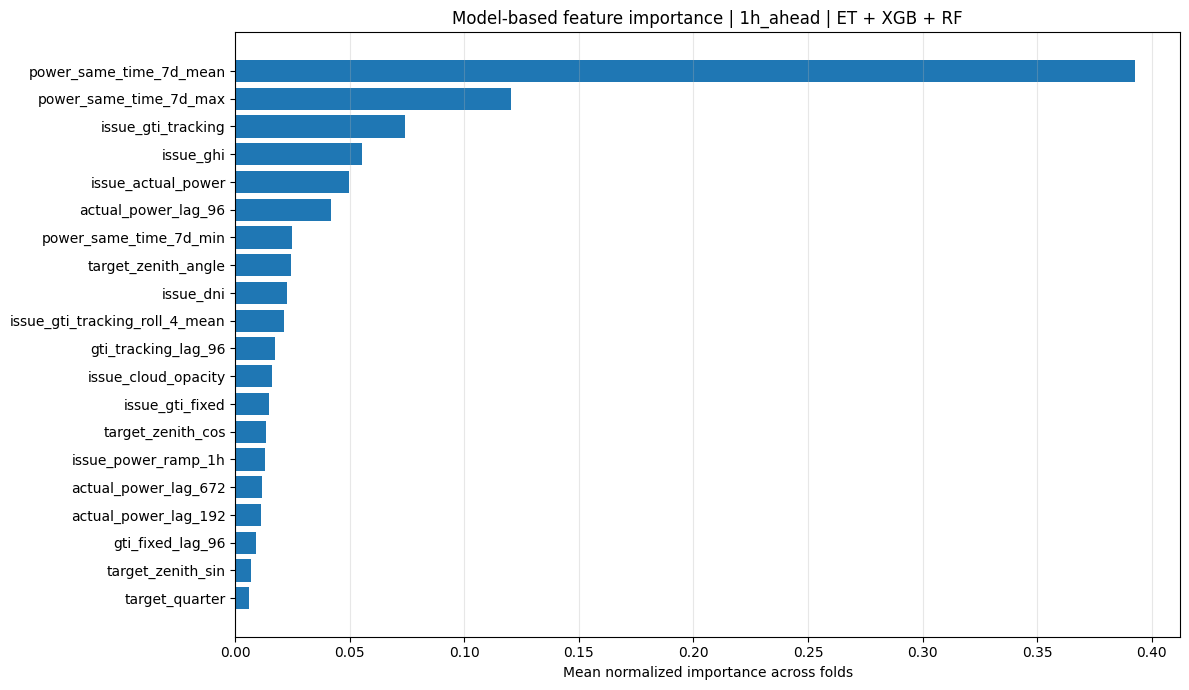

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/model_based_importance_top20_1h_ahead.png


,task,feature,feature_group,importance_mean,importance_std
121,2h_ahead,power_same_time_7d_mean,Same-time historical,0.422929,0.010163
120,2h_ahead,power_same_time_7d_max,Same-time historical,0.143310,0.009915
69,2h_ahead,actual_power_lag_96,Historical lag,0.060908,0.022167
80,2h_ahead,issue_dni,Issue-time measured,0.045157,0.008587
131,2h_ahead,target_zenith_angle,Target-time deterministic,0.033779,0.013085
122,2h_ahead,power_same_time_7d_min,Same-time historical,0.029905,0.008714
76,2h_ahead,issue_cloud_opacity,Issue-time measured,0.027941,0.003351
132,2h_ahead,target_zenith_cos,Target-time deterministic,0.022332,0.010016
73,2h_ahead,gti_tracking_lag_96,Historical lag,0.021269,0.004362
68,2h_ahead,actual_power_lag_672,Historical lag,0.017371,0.002201


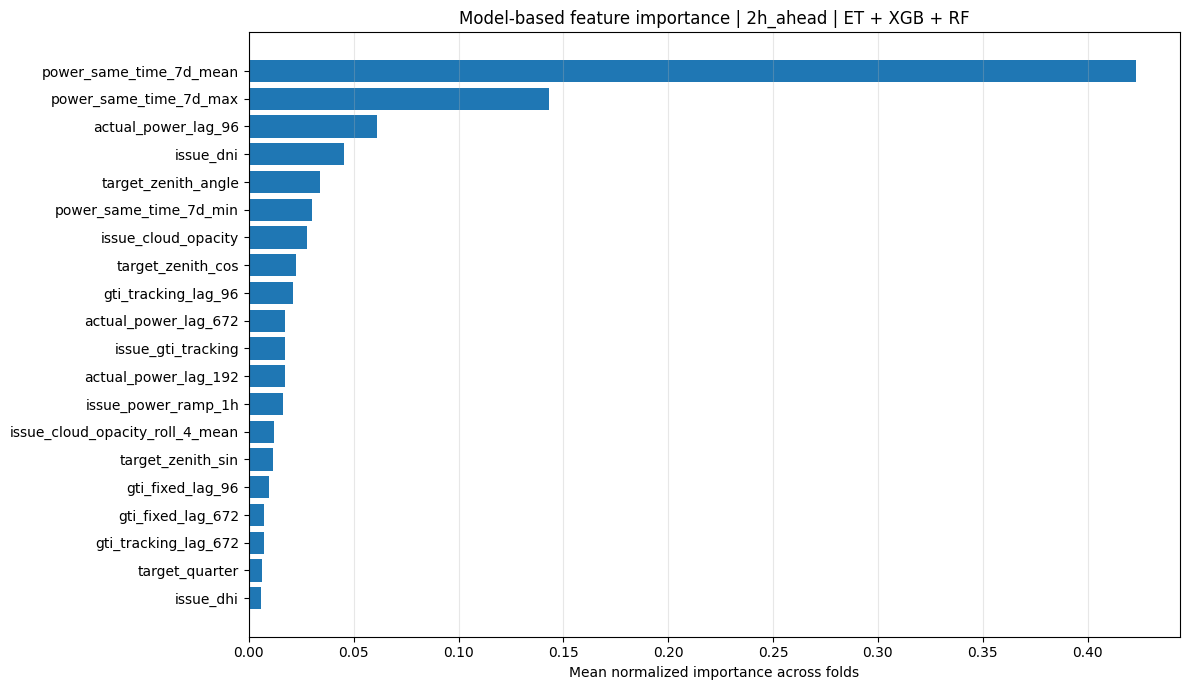

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/model_based_importance_top20_2h_ahead.png


,task,feature,feature_group,importance_mean,importance_std
188,3h_ahead,power_same_time_7d_mean,Same-time historical,0.433720,0.012267
187,3h_ahead,power_same_time_7d_max,Same-time historical,0.144012,0.008638
136,3h_ahead,actual_power_lag_96,Historical lag,0.072812,0.020865
198,3h_ahead,target_zenith_angle,Target-time deterministic,0.033533,0.012076
143,3h_ahead,issue_cloud_opacity,Issue-time measured,0.029662,0.003379
189,3h_ahead,power_same_time_7d_min,Same-time historical,0.028803,0.010043
199,3h_ahead,target_zenith_cos,Target-time deterministic,0.024044,0.011047
140,3h_ahead,gti_tracking_lag_96,Historical lag,0.021507,0.003955
135,3h_ahead,actual_power_lag_672,Historical lag,0.017728,0.002020
134,3h_ahead,actual_power_lag_192,Historical lag,0.017442,0.001457


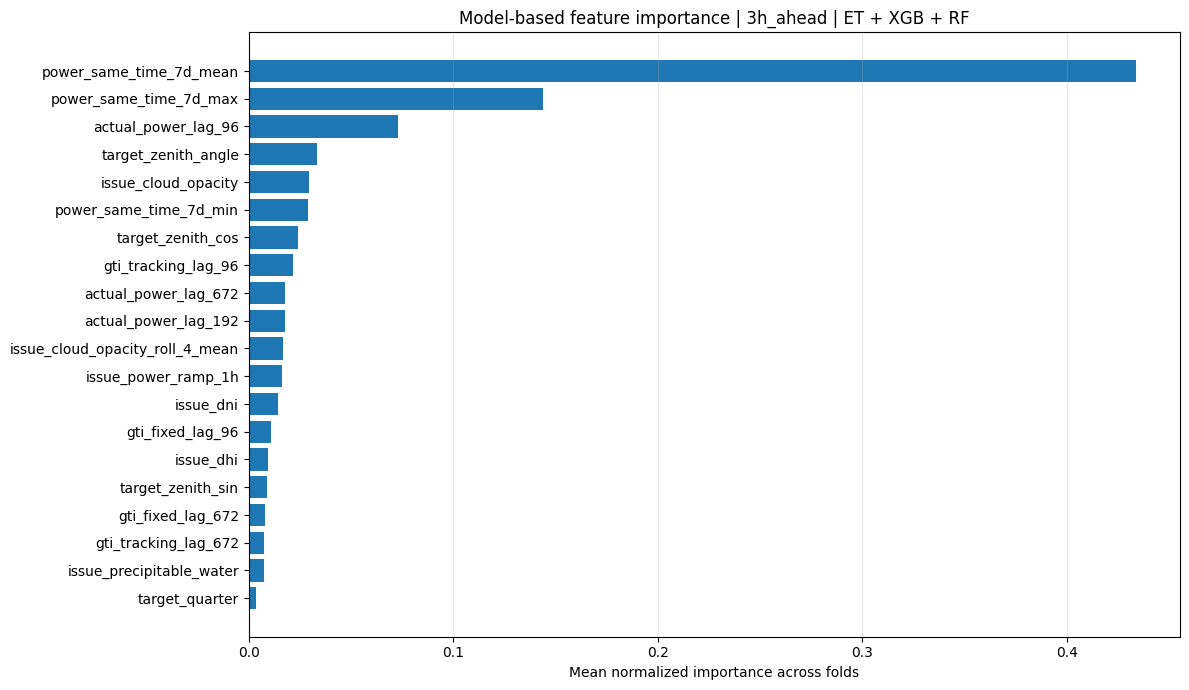

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/model_based_importance_top20_3h_ahead.png


In [ ]:
# ============================================================
# 9. Model-based importance for ET + XGB + RF
# ============================================================

model_based_rows = []

for task, info in xai_artifacts.items():
    feature_cols = info["feature_cols"]

    for fold_info in info["folds"]:
        fold_id = fold_info["fold"]["fold_id"]

        member_importances = []

        for member, model in fold_info["member_models"].items():
            imp = model_based_importance(model, feature_cols)
            member_importances.append(imp)

            for feature, value in zip(feature_cols, imp):
                model_based_rows.append({
                    "task": task,
                    "fold_id": fold_id,
                    "member": member,
                    "feature": feature,
                    "feature_group": assign_feature_group(feature),
                    "importance": value,
                })

        ens_imp = np.nanmean(np.vstack(member_importances), axis=0)
        ens_imp = normalize_importance(ens_imp)

        for feature, value in zip(feature_cols, ens_imp):
            model_based_rows.append({
                "task": task,
                "fold_id": fold_id,
                "member": "EnsembleMean",
                "feature": feature,
                "feature_group": assign_feature_group(feature),
                "importance": value,
            })

model_based_importance_df = pd.DataFrame(model_based_rows)
model_based_importance_df.to_csv(TABLE_DIR / "model_based_importance_by_fold_member.csv", index=False)

model_based_summary = (
    model_based_importance_df[model_based_importance_df["member"] == "EnsembleMean"]
    .groupby(["task", "feature", "feature_group"], as_index=False)
    .agg(
        importance_mean=("importance", "mean"),
        importance_std=("importance", "std")
    )
    .sort_values(["task", "importance_mean"], ascending=[True, False])
)

model_based_summary.to_csv(TABLE_DIR / "model_based_importance_summary.csv", index=False)

for task in HORIZONS.keys():
    df_task = model_based_summary[model_based_summary["task"] == task]
    display(df_task.head(20))
    save_barh(
        df=df_task,
        value_col="importance_mean",
        label_col="feature",
        title=f"Model-based feature importance | {task} | ET + XGB + RF",
        xlabel="Mean normalized importance across folds",
        path=FIG_DIR / f"model_based_importance_top20_{task}.png",
        top_n=20,
    )


Permutation importance: 1h_ahead
  fold 1: sample rows = 700
  fold 2: sample rows = 700
  fold 3: sample rows = 700
  fold 4: sample rows = 700
  fold 5: sample rows = 700
  fold 6: sample rows = 700

Permutation importance: 2h_ahead
  fold 1: sample rows = 700
  fold 2: sample rows = 700
  fold 3: sample rows = 700
  fold 4: sample rows = 700
  fold 5: sample rows = 700
  fold 6: sample rows = 700

Permutation importance: 3h_ahead
  fold 1: sample rows = 700
  fold 2: sample rows = 700
  fold 3: sample rows = 700
  fold 4: sample rows = 700
  fold 5: sample rows = 700
  fold 6: sample rows = 700


,task,feature,feature_group,perm_importance_mean,perm_importance_std
54,1h_ahead,power_same_time_7d_mean,Same-time historical,6.969232,1.924684
17,1h_ahead,issue_gti_tracking,Issue-time measured,5.551188,3.328402
53,1h_ahead,power_same_time_7d_max,Same-time historical,4.177830,2.533208
13,1h_ahead,issue_dni,Issue-time measured,1.109955,0.406063
7,1h_ahead,issue_actual_power,Issue-time measured,0.789695,0.247009
14,1h_ahead,issue_ghi,Issue-time measured,0.740741,0.242000
20,1h_ahead,issue_power_ramp_1h,Rolling/ramp,0.698949,0.255547
64,1h_ahead,target_zenith_angle,Target-time deterministic,0.579028,0.395679
18,1h_ahead,issue_gti_tracking_roll_4_mean,Rolling/ramp,0.481069,0.366319
9,1h_ahead,issue_cloud_opacity,Issue-time measured,0.376637,0.106449


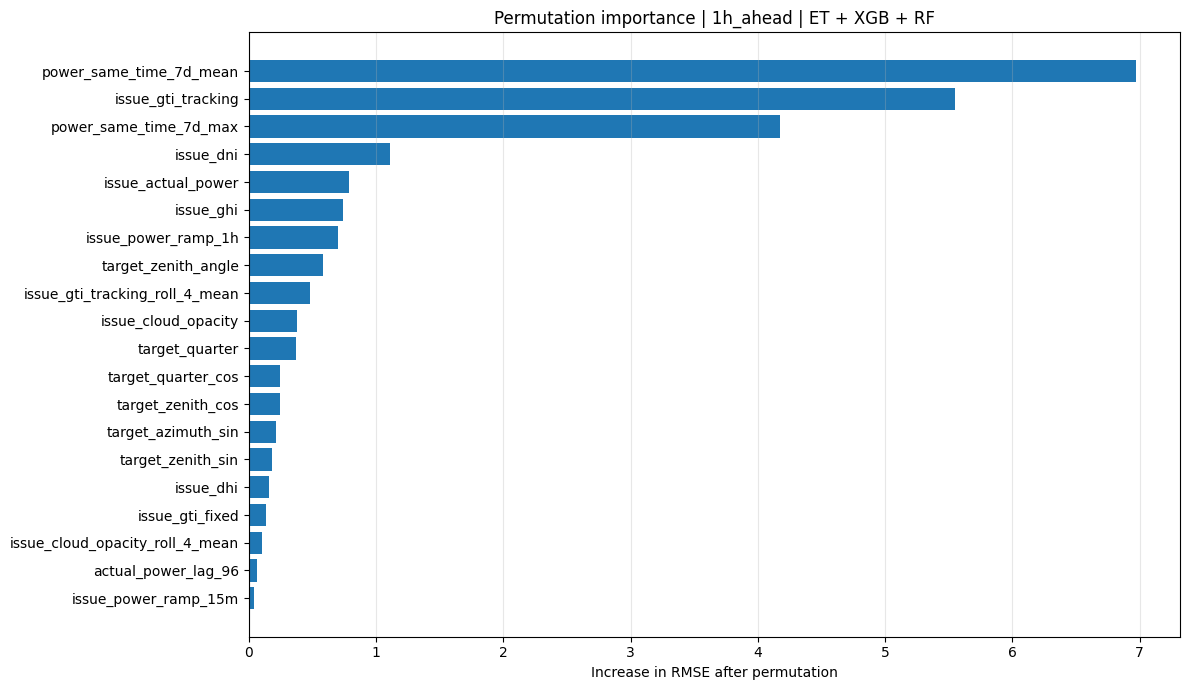

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/permutation_importance_top20_1h_ahead.png


,task,feature,feature_group,perm_importance_mean,perm_importance_std
121,2h_ahead,power_same_time_7d_mean,Same-time historical,7.909568,1.511309
120,2h_ahead,power_same_time_7d_max,Same-time historical,4.874083,2.387320
80,2h_ahead,issue_dni,Issue-time measured,2.098211,1.039383
76,2h_ahead,issue_cloud_opacity,Issue-time measured,1.023499,0.397344
131,2h_ahead,target_zenith_angle,Target-time deterministic,0.818061,0.473959
84,2h_ahead,issue_gti_tracking,Issue-time measured,0.644983,0.558286
79,2h_ahead,issue_dhi,Issue-time measured,0.530459,0.307576
87,2h_ahead,issue_power_ramp_1h,Rolling/ramp,0.406539,0.238249
77,2h_ahead,issue_cloud_opacity_roll_4_mean,Rolling/ramp,0.317459,0.143377
132,2h_ahead,target_zenith_cos,Target-time deterministic,0.263287,0.207980


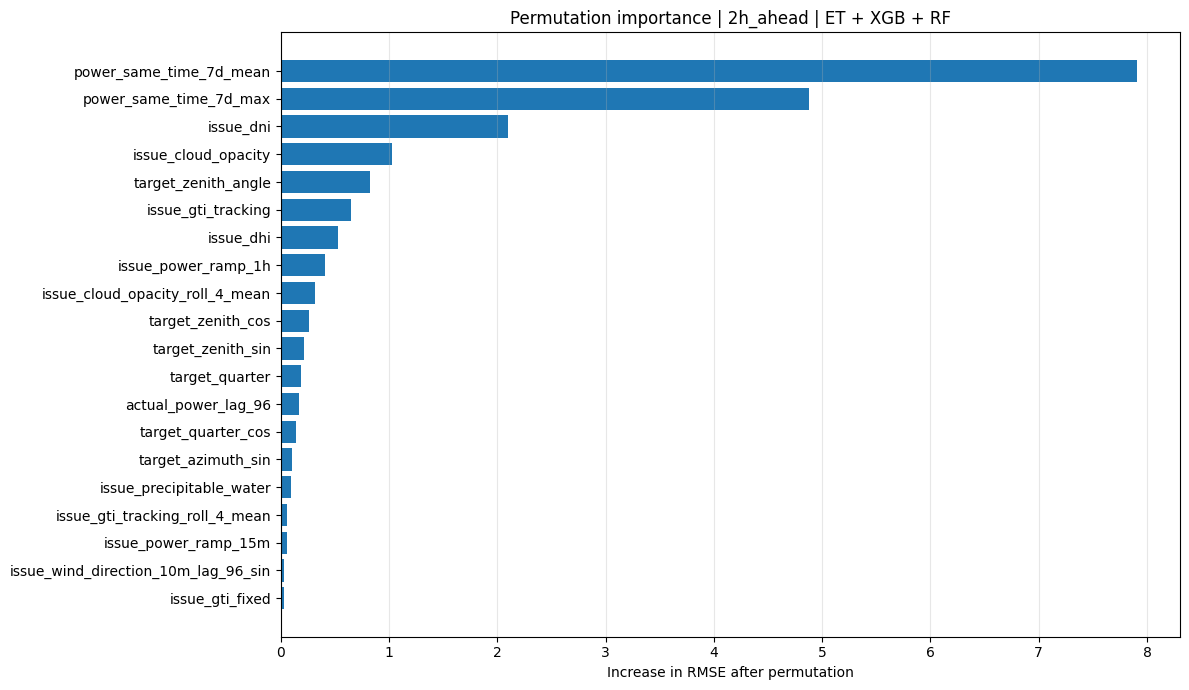

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/permutation_importance_top20_2h_ahead.png


,task,feature,feature_group,perm_importance_mean,perm_importance_std
188,3h_ahead,power_same_time_7d_mean,Same-time historical,8.449283,1.762158
187,3h_ahead,power_same_time_7d_max,Same-time historical,4.864848,2.223431
143,3h_ahead,issue_cloud_opacity,Issue-time measured,1.368513,0.686603
198,3h_ahead,target_zenith_angle,Target-time deterministic,0.986531,0.521351
147,3h_ahead,issue_dni,Issue-time measured,0.746882,0.503697
146,3h_ahead,issue_dhi,Issue-time measured,0.717623,0.377235
144,3h_ahead,issue_cloud_opacity_roll_4_mean,Rolling/ramp,0.383809,0.167235
154,3h_ahead,issue_power_ramp_1h,Rolling/ramp,0.336262,0.317396
199,3h_ahead,target_zenith_cos,Target-time deterministic,0.324568,0.220384
136,3h_ahead,actual_power_lag_96,Historical lag,0.266262,0.289599


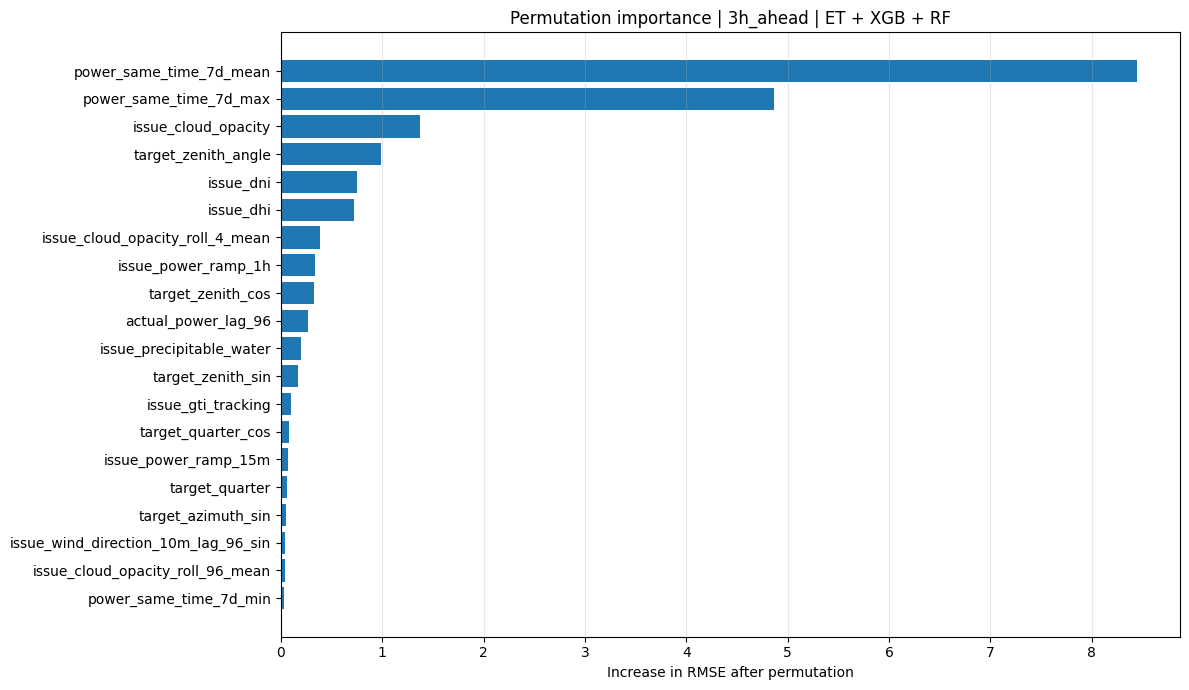

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/permutation_importance_top20_3h_ahead.png


In [ ]:
# ============================================================
# 10. Permutation importance for the mean ensemble
# ============================================================

permutation_rows = []

for task, info in xai_artifacts.items():
    print("\nPermutation importance:", task)

    feature_cols = info["feature_cols"]

    for fold_info in info["folds"]:
        fold = fold_info["fold"]
        fold_id = fold["fold_id"]
        test = fold["test"].copy()
        capacity = fold_info["capacity"]

        mask = daylight_xai_mask(test, capacity) if XAI_DAYLIGHT_ONLY else np.ones(len(test), dtype=bool)
        X_test = test.loc[mask, feature_cols]
        y_test = test.loc[mask, "y"]

        X_sample = sample_rows(X_test, PERM_SAMPLE_PER_FOLD, random_state=RANDOM_STATE + fold_id)
        y_sample = y_test.loc[X_sample.index]

        ensemble_model = MeanEnsembleWrapper(
            models=[fold_info["member_models"][m] for m in BEST_ENSEMBLE_MEMBERS],
            feature_cols=feature_cols,
        )

        print(f"  fold {fold_id}: sample rows = {len(X_sample)}")

        perm = permutation_importance(
            ensemble_model,
            X_sample,
            y_sample,
            scoring="neg_root_mean_squared_error",
            n_repeats=PERM_REPEATS,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

        for feature, mean_val, std_val in zip(feature_cols, perm.importances_mean, perm.importances_std):
            permutation_rows.append({
                "task": task,
                "fold_id": fold_id,
                "feature": feature,
                "feature_group": assign_feature_group(feature),
                "importance_mean": mean_val,
                "importance_std": std_val,
                "sample_rows": len(X_sample),
            })

permutation_importance_df = pd.DataFrame(permutation_rows)
permutation_importance_df.to_csv(TABLE_DIR / "permutation_importance_by_fold.csv", index=False)

permutation_summary = (
    permutation_importance_df
    .groupby(["task", "feature", "feature_group"], as_index=False)
    .agg(
        perm_importance_mean=("importance_mean", "mean"),
        perm_importance_std=("importance_mean", "std")
    )
    .sort_values(["task", "perm_importance_mean"], ascending=[True, False])
)

permutation_summary.to_csv(TABLE_DIR / "permutation_importance_summary.csv", index=False)

for task in HORIZONS.keys():
    df_task = permutation_summary[permutation_summary["task"] == task]
    display(df_task.head(20))
    save_barh(
        df=df_task,
        value_col="perm_importance_mean",
        label_col="feature",
        title=f"Permutation importance | {task} | ET + XGB + RF",
        xlabel="Increase in RMSE after permutation",
        path=FIG_DIR / f"permutation_importance_top20_{task}.png",
        top_n=20,
    )


SHAP: 1h_ahead
  fold 1 | ExtraTrees | sample rows=350
  fold 1 | XGBoost | sample rows=350
  fold 1 | RandomForest | sample rows=350
  fold 2 | ExtraTrees | sample rows=350
  fold 2 | XGBoost | sample rows=350
  fold 2 | RandomForest | sample rows=350
  fold 3 | ExtraTrees | sample rows=350
  fold 3 | XGBoost | sample rows=350
  fold 3 | RandomForest | sample rows=350
  fold 4 | ExtraTrees | sample rows=350
  fold 4 | XGBoost | sample rows=350
  fold 4 | RandomForest | sample rows=350
  fold 5 | ExtraTrees | sample rows=350
  fold 5 | XGBoost | sample rows=350
  fold 5 | RandomForest | sample rows=350
  fold 6 | ExtraTrees | sample rows=350
  fold 6 | XGBoost | sample rows=350
  fold 6 | RandomForest | sample rows=350


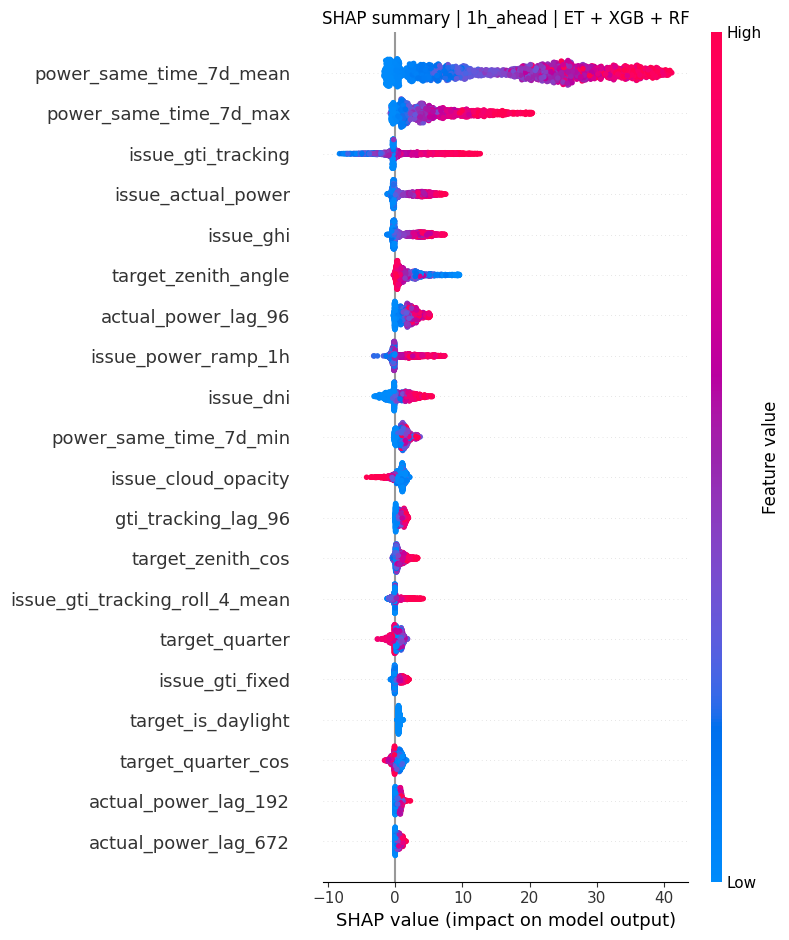

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/shap_summary_beeswarm_1h_ahead.png


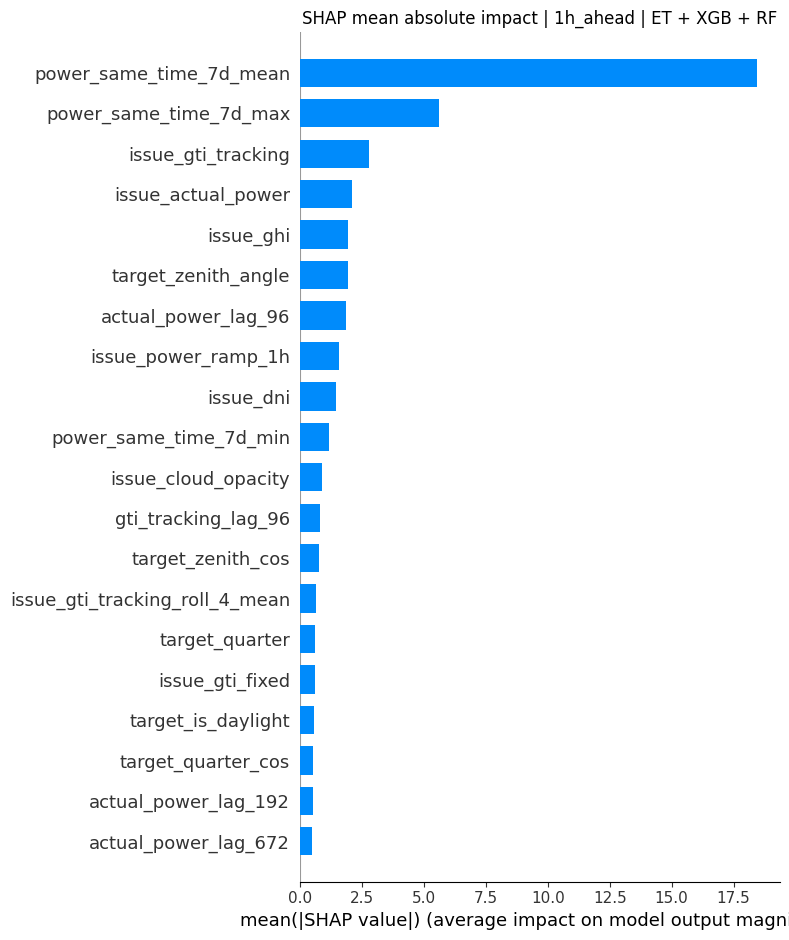

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/shap_summary_bar_1h_ahead.png

SHAP: 2h_ahead
  fold 1 | ExtraTrees | sample rows=350
  fold 1 | XGBoost | sample rows=350
  fold 1 | RandomForest | sample rows=350
  fold 2 | ExtraTrees | sample rows=350
  fold 2 | XGBoost | sample rows=350
  fold 2 | RandomForest | sample rows=350
  fold 3 | ExtraTrees | sample rows=350
  fold 3 | XGBoost | sample rows=350
  fold 3 | RandomForest | sample rows=350
  fold 4 | ExtraTrees | sample rows=350
  fold 4 | XGBoost | sample rows=350
  fold 4 | RandomForest | sample rows=350
  fold 5 | ExtraTrees | sample rows=350
  fold 5 | XGBoost | sample rows=350
  fold 5 | RandomForest | sample rows=350
  fold 6 | ExtraTrees | sample rows=350
  fold 6 | XGBoost | sample rows=350
  fold 6 | RandomForest | sample rows=350


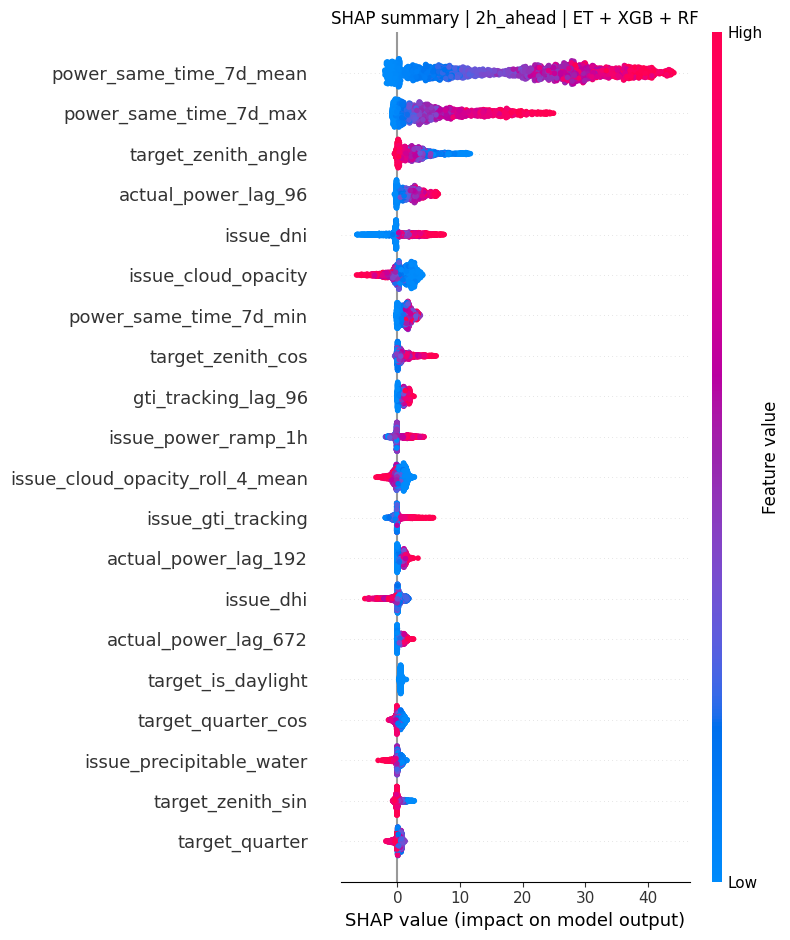

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/shap_summary_beeswarm_2h_ahead.png


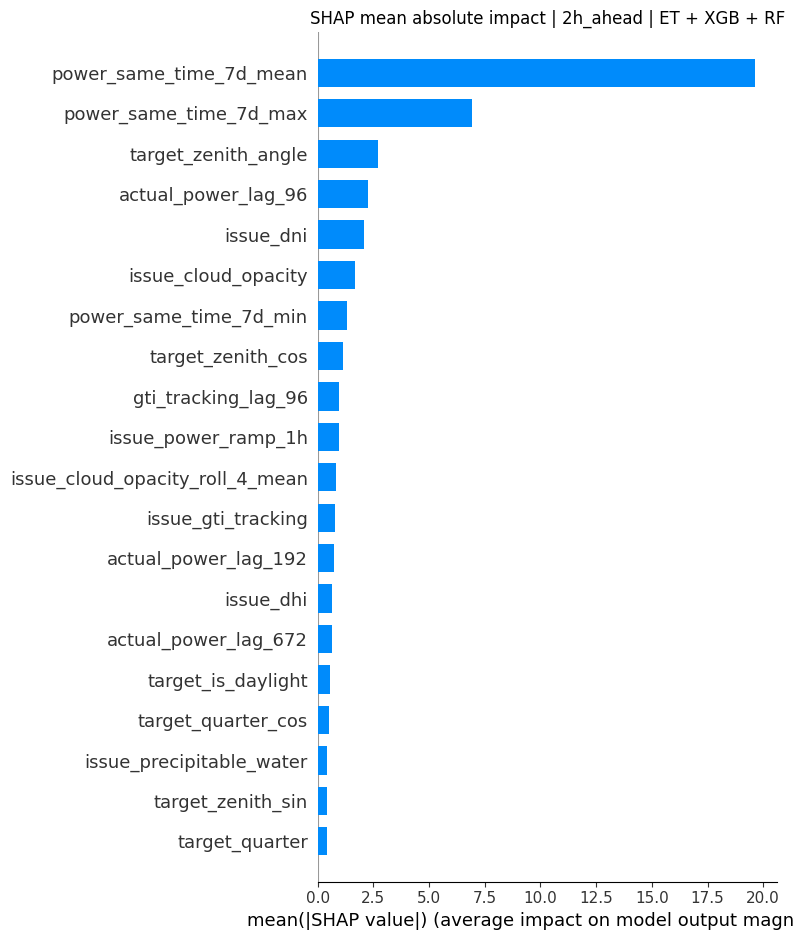

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/shap_summary_bar_2h_ahead.png

SHAP: 3h_ahead
  fold 1 | ExtraTrees | sample rows=350
  fold 1 | XGBoost | sample rows=350
  fold 1 | RandomForest | sample rows=350
  fold 2 | ExtraTrees | sample rows=350
  fold 2 | XGBoost | sample rows=350
  fold 2 | RandomForest | sample rows=350
  fold 3 | ExtraTrees | sample rows=350
  fold 3 | XGBoost | sample rows=350
  fold 3 | RandomForest | sample rows=350
  fold 4 | ExtraTrees | sample rows=350
  fold 4 | XGBoost | sample rows=350
  fold 4 | RandomForest | sample rows=350
  fold 5 | ExtraTrees | sample rows=350
  fold 5 | XGBoost | sample rows=350
  fold 5 | RandomForest | sample rows=350
  fold 6 | ExtraTrees | sample rows=350
  fold 6 | XGBoost | sample rows=350
  fold 6 | RandomForest | sample rows=350


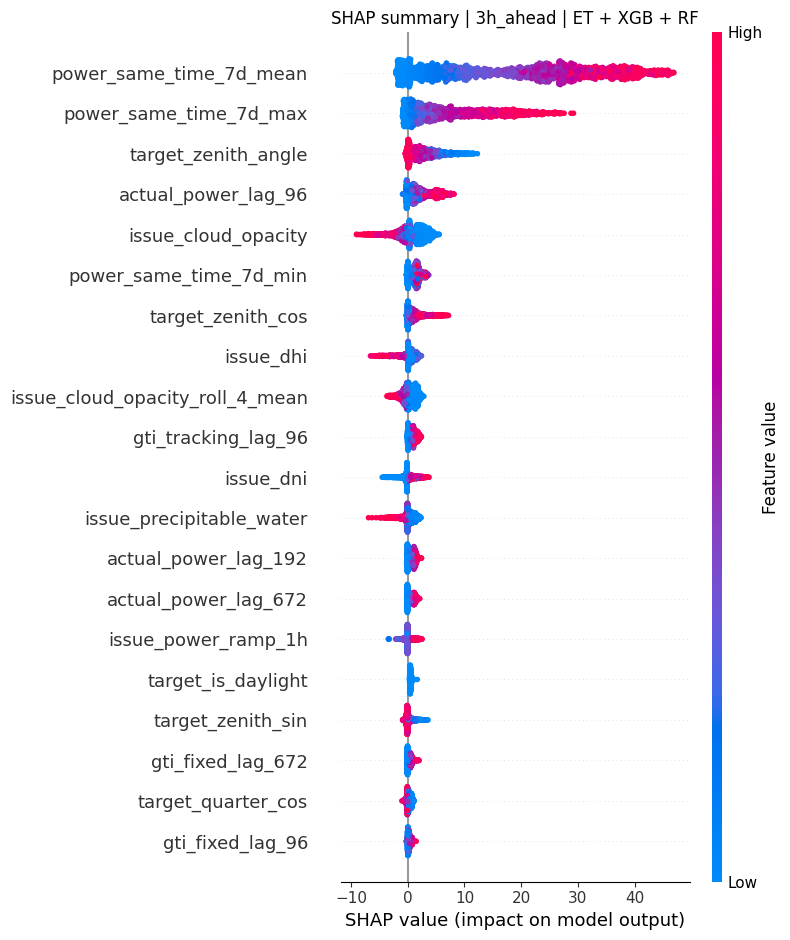

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/shap_summary_beeswarm_3h_ahead.png


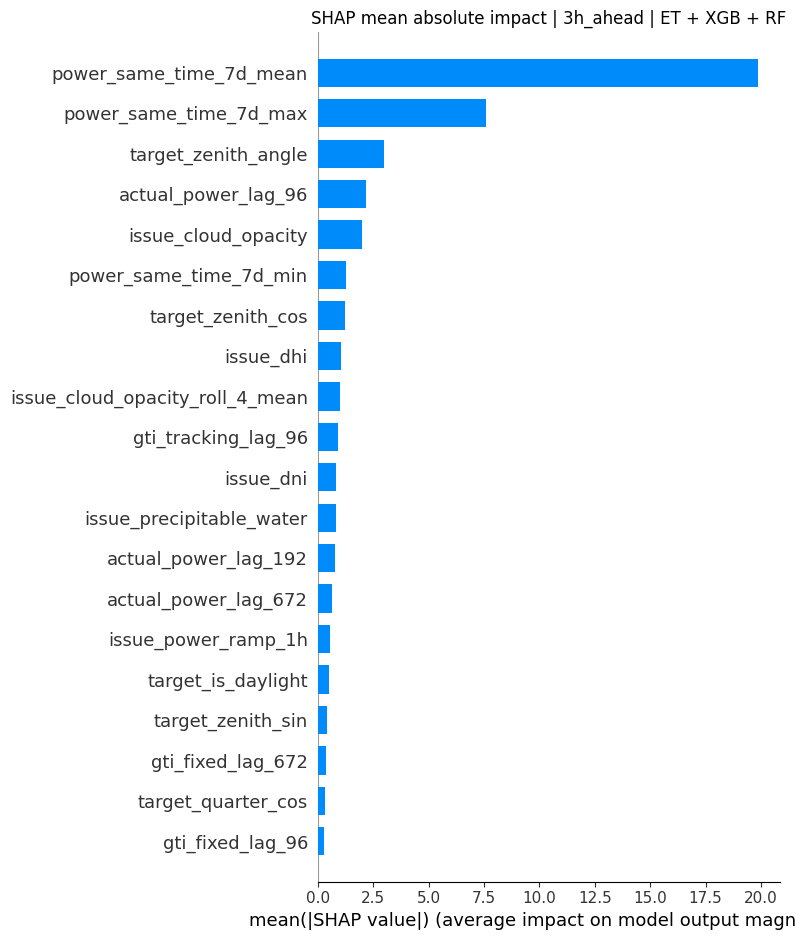

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/shap_summary_bar_3h_ahead.png


,task,feature,feature_group,mean_abs_shap,std_abs_shap
54,1h_ahead,power_same_time_7d_mean,Same-time historical,18.451136,3.790718
53,1h_ahead,power_same_time_7d_max,Same-time historical,5.610803,2.534569
17,1h_ahead,issue_gti_tracking,Issue-time measured,2.804615,1.485804
7,1h_ahead,issue_actual_power,Issue-time measured,2.102713,0.644149
14,1h_ahead,issue_ghi,Issue-time measured,1.946200,0.582204
64,1h_ahead,target_zenith_angle,Target-time deterministic,1.924928,1.497371
2,1h_ahead,actual_power_lag_96,Historical lag,1.839250,0.651147
20,1h_ahead,issue_power_ramp_1h,Rolling/ramp,1.560083,0.449326
13,1h_ahead,issue_dni,Issue-time measured,1.455698,0.246442
55,1h_ahead,power_same_time_7d_min,Same-time historical,1.179525,0.425492


,task,fold_id,timestamp,actual,raw_prediction,abs_error,expected_value
0,1h_ahead,1,2019-02-22 13:45:00,42.08736,75.806101,33.718741,3.826101
1,1h_ahead,2,2019-04-26 11:45:00,38.89677,68.070269,29.173499,3.553260
2,1h_ahead,3,2019-05-09 17:45:00,70.10080,32.590451,37.510349,3.418911
3,1h_ahead,4,2019-07-05 16:15:00,80.29494,45.037959,35.256981,3.464196
4,1h_ahead,5,2019-09-06 15:45:00,86.35926,43.017890,43.341370,3.690977


In [ ]:
# ============================================================
# 11. TreeSHAP global explanations
# ============================================================

if not SHAP_AVAILABLE:
    raise RuntimeError("SHAP is not available. Please check the installation cell.")

shap_rows = []
local_records = []

def compute_tree_shap_values(model, X_sample):
    explainer = shap.TreeExplainer(model)
    values = explainer.shap_values(X_sample)

    # Some SHAP versions return list for special cases.
    if isinstance(values, list):
        values = values[0]

    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = np.asarray(expected_value).ravel()[0]

    return np.asarray(values), float(expected_value)


for task, info in xai_artifacts.items():
    print("\nSHAP:", task)
    feature_cols = info["feature_cols"]

    task_shap_values = []
    task_X_samples = []

    for fold_info in info["folds"]:
        fold = fold_info["fold"]
        fold_id = fold["fold_id"]
        test = fold["test"].copy()
        capacity = fold_info["capacity"]

        mask = daylight_xai_mask(test, capacity) if XAI_DAYLIGHT_ONLY else np.ones(len(test), dtype=bool)
        X_test = test.loc[mask, feature_cols]
        y_test = test.loc[mask, "y"]

        if len(X_test) == 0:
            continue

        X_sample = sample_rows(X_test, SHAP_SAMPLE_PER_FOLD, random_state=RANDOM_STATE + fold_id)
        y_sample = y_test.loc[X_sample.index]

        member_shap_values = []
        member_expected_values = []

        for member in BEST_ENSEMBLE_MEMBERS:
            print(f"  fold {fold_id} | {member} | sample rows={len(X_sample)}")
            model = fold_info["member_models"][member]
            values, expected = compute_tree_shap_values(model, X_sample)
            member_shap_values.append(values)
            member_expected_values.append(expected)

            mean_abs = np.abs(values).mean(axis=0)
            for feature, val in zip(feature_cols, mean_abs):
                shap_rows.append({
                    "task": task,
                    "fold_id": fold_id,
                    "member": member,
                    "feature": feature,
                    "feature_group": assign_feature_group(feature),
                    "mean_abs_shap": val,
                    "sample_rows": len(X_sample),
                })

        # Linear averaging is valid for a simple mean ensemble before external post-processing.
        ensemble_shap = np.mean(member_shap_values, axis=0)
        ensemble_expected = float(np.mean(member_expected_values))

        mean_abs_ens = np.abs(ensemble_shap).mean(axis=0)
        for feature, val in zip(feature_cols, mean_abs_ens):
            shap_rows.append({
                "task": task,
                "fold_id": fold_id,
                "member": "EnsembleMean",
                "feature": feature,
                "feature_group": assign_feature_group(feature),
                "mean_abs_shap": val,
                "sample_rows": len(X_sample),
            })

        # Store for global summary plot.
        task_shap_values.append(ensemble_shap)
        task_X_samples.append(X_sample)

        # Local explanation for the highest raw ensemble absolute error in this sampled fold.
        raw_member_preds = [
            fold_info["member_models"][m].predict(X_sample)
            for m in BEST_ENSEMBLE_MEMBERS
        ]
        raw_ens_pred = np.mean(raw_member_preds, axis=0)
        local_err = np.abs(y_sample.to_numpy() - raw_ens_pred)
        worst_pos = int(np.argmax(local_err))

        local_records.append({
            "task": task,
            "fold_id": fold_id,
            "timestamp": str(X_sample.index[worst_pos]),
            "actual": float(y_sample.iloc[worst_pos]),
            "raw_prediction": float(raw_ens_pred[worst_pos]),
            "abs_error": float(local_err[worst_pos]),
            "expected_value": ensemble_expected,
        })

        local_df = pd.DataFrame({
            "feature": feature_cols,
            "feature_group": [assign_feature_group(f) for f in feature_cols],
            "shap_value": ensemble_shap[worst_pos],
            "feature_value": X_sample.iloc[worst_pos].to_numpy(),
            "abs_shap": np.abs(ensemble_shap[worst_pos]),
        }).sort_values("abs_shap", ascending=False)

        local_df.to_csv(TABLE_DIR / f"local_shap_worst_sample_{task}_fold_{fold_id:02d}.csv", index=False)

    if len(task_shap_values) > 0:
        shap_all = np.vstack(task_shap_values)
        X_all = pd.concat(task_X_samples, axis=0)

        # SHAP beeswarm summary plot.
        plt.figure()
        shap.summary_plot(
            shap_all,
            X_all[feature_cols],
            plot_type="dot",
            max_display=20,
            show=False
        )
        plt.title(f"SHAP summary | {task} | ET + XGB + RF")
        plt.tight_layout()
        out_path = FIG_DIR / f"shap_summary_beeswarm_{task}.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", out_path)

        # SHAP bar summary plot.
        plt.figure()
        shap.summary_plot(
            shap_all,
            X_all[feature_cols],
            plot_type="bar",
            max_display=20,
            show=False
        )
        plt.title(f"SHAP mean absolute impact | {task} | ET + XGB + RF")
        plt.tight_layout()
        out_path = FIG_DIR / f"shap_summary_bar_{task}.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", out_path)

shap_importance_df = pd.DataFrame(shap_rows)
shap_importance_df.to_csv(TABLE_DIR / "shap_importance_by_fold_member.csv", index=False)

shap_summary = (
    shap_importance_df[shap_importance_df["member"] == "EnsembleMean"]
    .groupby(["task", "feature", "feature_group"], as_index=False)
    .agg(
        mean_abs_shap=("mean_abs_shap", "mean"),
        std_abs_shap=("mean_abs_shap", "std"),
    )
    .sort_values(["task", "mean_abs_shap"], ascending=[True, False])
)

shap_summary.to_csv(TABLE_DIR / "shap_importance_summary.csv", index=False)

local_summary_df = pd.DataFrame(local_records)
local_summary_df.to_csv(TABLE_DIR / "local_worst_sample_summary.csv", index=False)

display(shap_summary.head(30))
display(local_summary_df.head())

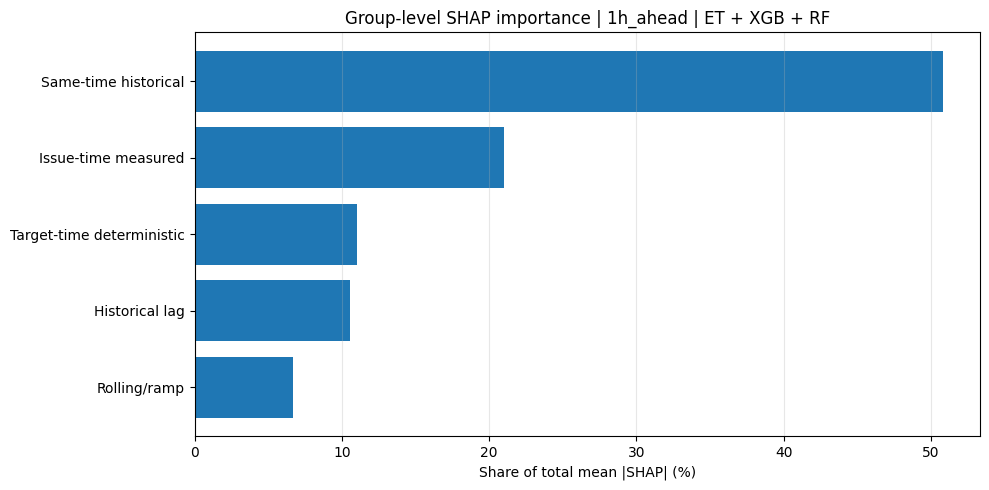

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/shap_group_importance_1h_ahead.png


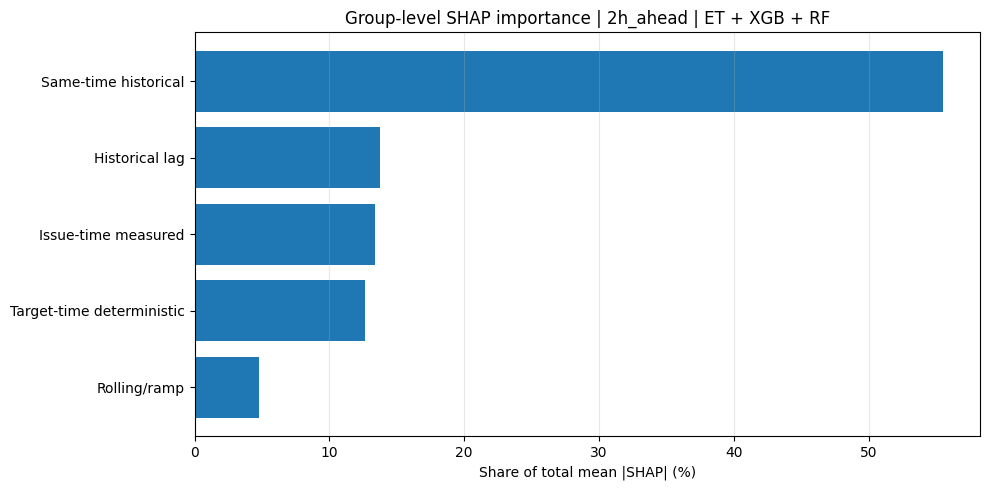

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/shap_group_importance_2h_ahead.png


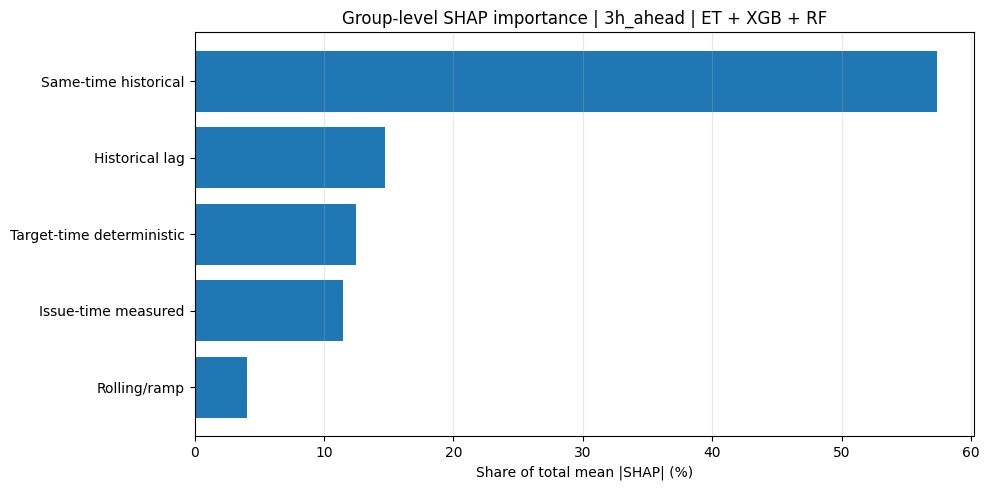

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/shap_group_importance_3h_ahead.png


,task,feature_group,group_mean_abs_shap,group_share
3,1h_ahead,Same-time historical,25.241464,0.507966
1,1h_ahead,Issue-time measured,10.441202,0.210122
4,1h_ahead,Target-time deterministic,5.467767,0.110035
0,1h_ahead,Historical lag,5.236987,0.105391
2,1h_ahead,Rolling/ramp,3.303817,0.066487
8,2h_ahead,Same-time historical,27.897469,0.554845
5,2h_ahead,Historical lag,6.905648,0.137344
6,2h_ahead,Issue-time measured,6.725408,0.133760
9,2h_ahead,Target-time deterministic,6.337933,0.126053
7,2h_ahead,Rolling/ramp,2.413322,0.047998


In [ ]:
# ============================================================
# 12. SHAP group-level importance
# ============================================================

group_summary = (
    shap_summary
    .groupby(["task", "feature_group"], as_index=False)
    .agg(group_mean_abs_shap=("mean_abs_shap", "sum"))
)

# Normalize within each horizon for easier interpretation.
group_summary["group_share"] = (
    group_summary["group_mean_abs_shap"]
    / group_summary.groupby("task")["group_mean_abs_shap"].transform("sum")
)

group_summary = group_summary.sort_values(["task", "group_share"], ascending=[True, False])
group_summary.to_csv(TABLE_DIR / "shap_group_importance_summary.csv", index=False)

for task in HORIZONS.keys():
    df_task = group_summary[group_summary["task"] == task].sort_values("group_share", ascending=True)

    plt.figure(figsize=(10, 5))
    plt.barh(df_task["feature_group"], df_task["group_share"] * 100)
    plt.xlabel("Share of total mean |SHAP| (%)")
    plt.title(f"Group-level SHAP importance | {task} | ET + XGB + RF")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    out_path = FIG_DIR / f"shap_group_importance_{task}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

display(group_summary)

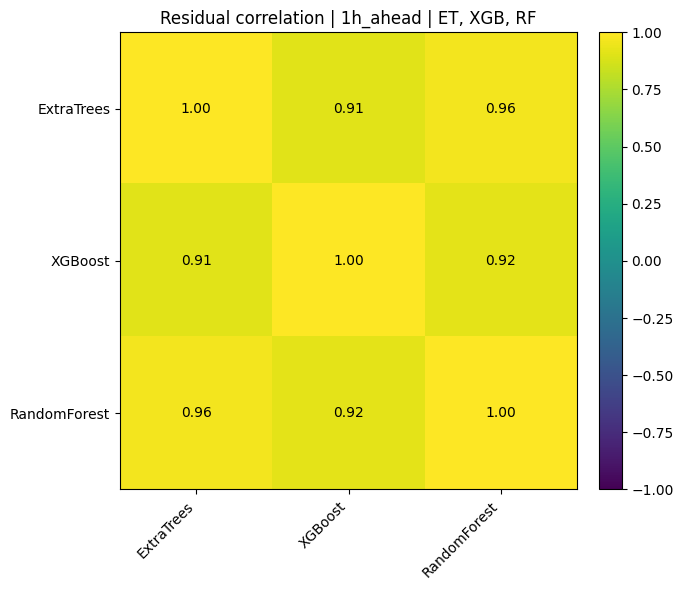

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/residual_correlation_1h_ahead.png


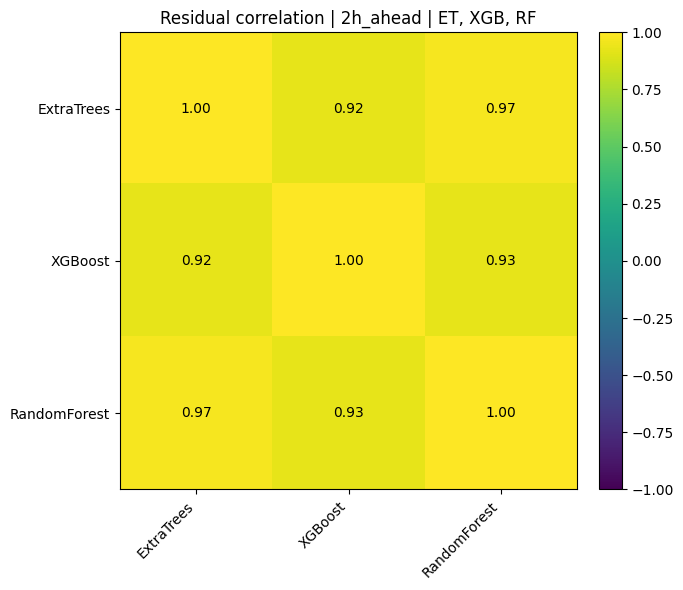

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/residual_correlation_2h_ahead.png


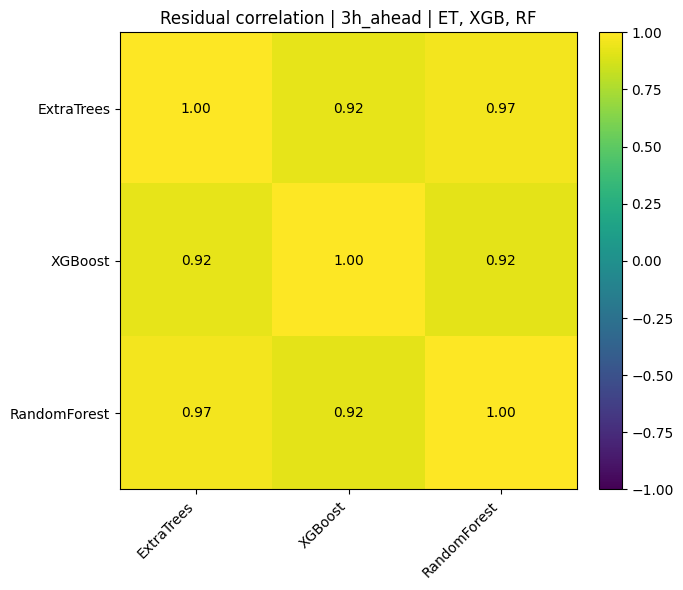

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/residual_correlation_3h_ahead.png


,task,model_a,model_b,residual_correlation
0,1h_ahead,ExtraTrees,ExtraTrees,1.000000
1,1h_ahead,ExtraTrees,XGBoost,0.908746
2,1h_ahead,ExtraTrees,RandomForest,0.964726
3,1h_ahead,XGBoost,ExtraTrees,0.908746
4,1h_ahead,XGBoost,XGBoost,1.000000
5,1h_ahead,XGBoost,RandomForest,0.920867
6,1h_ahead,RandomForest,ExtraTrees,0.964726
7,1h_ahead,RandomForest,XGBoost,0.920867
8,1h_ahead,RandomForest,RandomForest,1.000000
9,2h_ahead,ExtraTrees,ExtraTrees,1.000000


In [ ]:
# ============================================================
# 13. Residual correlation between ET, XGB, and RF
# ============================================================

res_corr_rows = []

for task, info in xai_artifacts.items():
    residual_frames = []

    for fold_info in info["folds"]:
        fold = fold_info["fold"]
        test = fold["test"].copy()
        capacity = fold_info["capacity"]
        y_true = test["y"].to_numpy(dtype=float)

        member_residuals = {}
        for member in BEST_ENSEMBLE_MEMBERS:
            pred = fold_info["member_models"][member].predict(test[info["feature_cols"]])
            pred = postprocess_prediction(test, pred, capacity)
            member_residuals[member] = y_true - pred

        residual_frames.append(pd.DataFrame(member_residuals, index=test.index))

    residual_df = pd.concat(residual_frames, axis=0)
    corr_df = residual_df.corr()

    corr_df.to_csv(TABLE_DIR / f"residual_correlation_{task}.csv")

    save_corr_heatmap(
        corr_df,
        title=f"Residual correlation | {task} | ET, XGB, RF",
        path=FIG_DIR / f"residual_correlation_{task}.png"
    )

    for a in corr_df.index:
        for b in corr_df.columns:
            res_corr_rows.append({
                "task": task,
                "model_a": a,
                "model_b": b,
                "residual_correlation": corr_df.loc[a, b],
            })

residual_corr_long = pd.DataFrame(res_corr_rows)
residual_corr_long.to_csv(TABLE_DIR / "residual_correlation_long.csv", index=False)

display(residual_corr_long.head(20))

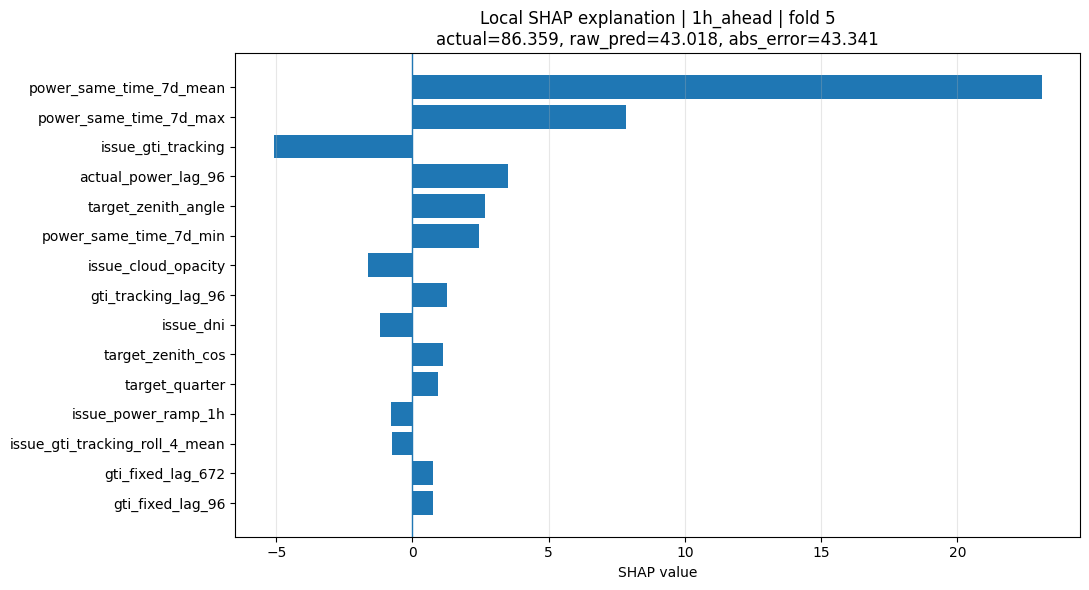

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/local_shap_top15_worst_error_1h_ahead.png


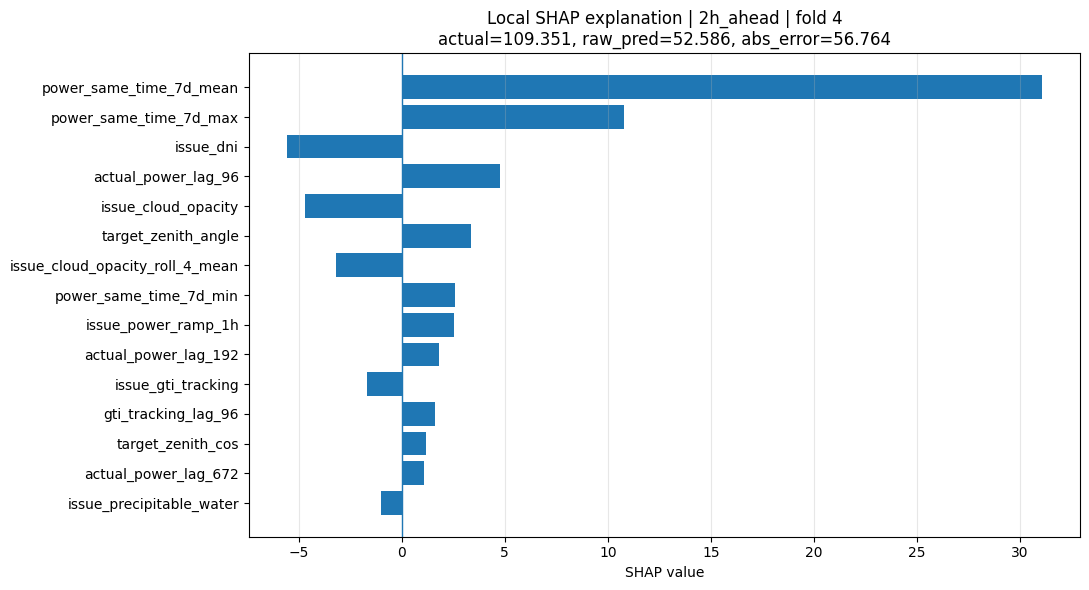

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/local_shap_top15_worst_error_2h_ahead.png


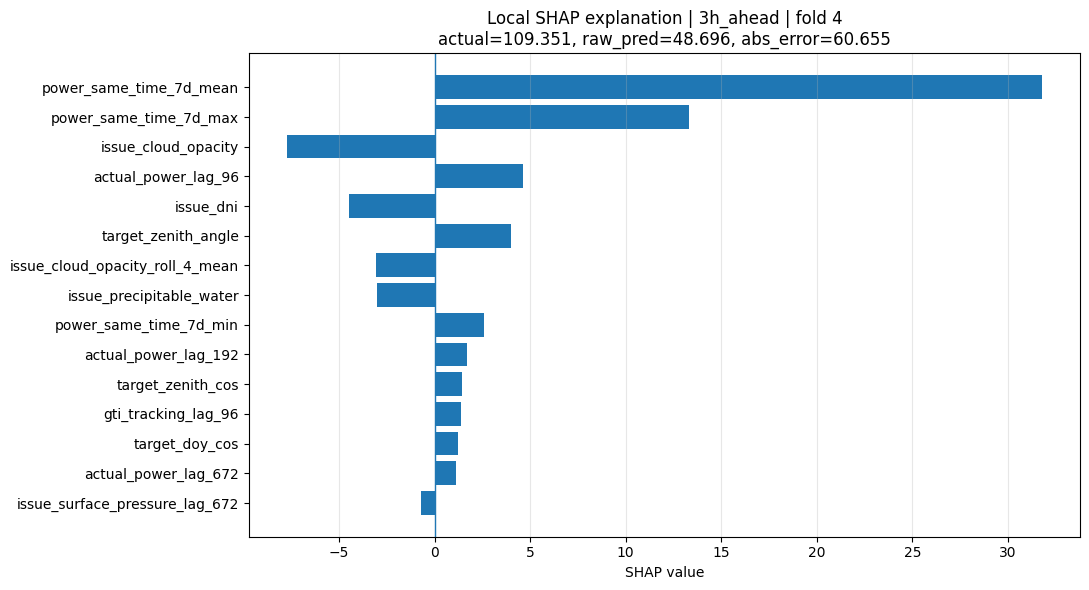

Saved: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures/local_shap_top15_worst_error_3h_ahead.png


In [ ]:
# ============================================================
# 14. Local SHAP plots for worst sampled errors
# ============================================================

# This cell reads local SHAP CSVs created above and plots the largest-error sample per horizon.
for task in HORIZONS.keys():
    local_files = sorted(TABLE_DIR.glob(f"local_shap_worst_sample_{task}_fold_*.csv"))
    if not local_files:
        continue

    # Pick the fold with the largest sampled local error.
    local_meta = local_summary_df[local_summary_df["task"] == task].copy()
    if len(local_meta) == 0:
        continue

    row = local_meta.sort_values("abs_error", ascending=False).iloc[0]
    fold_id = int(row["fold_id"])
    local_path = TABLE_DIR / f"local_shap_worst_sample_{task}_fold_{fold_id:02d}.csv"

    local_df = pd.read_csv(local_path).sort_values("abs_shap", ascending=False).head(15).iloc[::-1]

    plt.figure(figsize=(11, 6))
    plt.barh(local_df["feature"], local_df["shap_value"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("SHAP value")
    plt.title(
        f"Local SHAP explanation | {task} | fold {fold_id}\n"
        f"actual={row['actual']:.3f}, raw_pred={row['raw_prediction']:.3f}, abs_error={row['abs_error']:.3f}"
    )
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()

    out_path = FIG_DIR / f"local_shap_top15_worst_error_{task}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

In [ ]:
# ============================================================
# 15. Final report table for the paper/slide
# ============================================================

top_shap_features = (
    shap_summary
    .sort_values(["task", "mean_abs_shap"], ascending=[True, False])
    .groupby("task")
    .head(15)
)

top_perm_features = (
    permutation_summary
    .sort_values(["task", "perm_importance_mean"], ascending=[True, False])
    .groupby("task")
    .head(15)
)

top_shap_features.to_csv(TABLE_DIR / "top15_shap_features_each_horizon.csv", index=False)
top_perm_features.to_csv(TABLE_DIR / "top15_permutation_features_each_horizon.csv", index=False)

print("Key output folders:")
print("Tables:", TABLE_DIR)
print("Figures:", FIG_DIR)
print("Saved fold models:", MODEL_DIR)

print("\nTop SHAP features:")
display(top_shap_features)

print("\nTop permutation features:")
display(top_perm_features)

print("\nGroup-level SHAP importance:")
display(group_summary)

print("\nET+XGB+RF CV summary:")
display(et_xgb_rf_summary)

Key output folders:
Tables: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/tables
Figures: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/figures
Saved fold models: /content/drive/MyDrive/data4dav/pv_multi_model_blocked_seasonal_kfold_results/xai_et_xgb_rf/saved_fold_models

Top SHAP features:


,task,feature,feature_group,mean_abs_shap,std_abs_shap
54,1h_ahead,power_same_time_7d_mean,Same-time historical,18.451136,3.790718
53,1h_ahead,power_same_time_7d_max,Same-time historical,5.610803,2.534569
17,1h_ahead,issue_gti_tracking,Issue-time measured,2.804615,1.485804
7,1h_ahead,issue_actual_power,Issue-time measured,2.102713,0.644149
14,1h_ahead,issue_ghi,Issue-time measured,1.946200,0.582204
64,1h_ahead,target_zenith_angle,Target-time deterministic,1.924928,1.497371
2,1h_ahead,actual_power_lag_96,Historical lag,1.839250,0.651147
20,1h_ahead,issue_power_ramp_1h,Rolling/ramp,1.560083,0.449326
13,1h_ahead,issue_dni,Issue-time measured,1.455698,0.246442
55,1h_ahead,power_same_time_7d_min,Same-time historical,1.179525,0.425492



Top permutation features:


,task,feature,feature_group,perm_importance_mean,perm_importance_std
54,1h_ahead,power_same_time_7d_mean,Same-time historical,6.969232,1.924684
17,1h_ahead,issue_gti_tracking,Issue-time measured,5.551188,3.328402
53,1h_ahead,power_same_time_7d_max,Same-time historical,4.177830,2.533208
13,1h_ahead,issue_dni,Issue-time measured,1.109955,0.406063
7,1h_ahead,issue_actual_power,Issue-time measured,0.789695,0.247009
14,1h_ahead,issue_ghi,Issue-time measured,0.740741,0.242000
20,1h_ahead,issue_power_ramp_1h,Rolling/ramp,0.698949,0.255547
64,1h_ahead,target_zenith_angle,Target-time deterministic,0.579028,0.395679
18,1h_ahead,issue_gti_tracking_roll_4_mean,Rolling/ramp,0.481069,0.366319
9,1h_ahead,issue_cloud_opacity,Issue-time measured,0.376637,0.106449



Group-level SHAP importance:


,task,feature_group,group_mean_abs_shap,group_share
3,1h_ahead,Same-time historical,25.241464,0.507966
1,1h_ahead,Issue-time measured,10.441202,0.210122
4,1h_ahead,Target-time deterministic,5.467767,0.110035
0,1h_ahead,Historical lag,5.236987,0.105391
2,1h_ahead,Rolling/ramp,3.303817,0.066487
8,2h_ahead,Same-time historical,27.897469,0.554845
5,2h_ahead,Historical lag,6.905648,0.137344
6,2h_ahead,Issue-time measured,6.725408,0.133760
9,2h_ahead,Target-time deterministic,6.337933,0.126053
7,2h_ahead,Rolling/ramp,2.413322,0.047998



ET+XGB+RF CV summary:


,task,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std,DS_MAPE_mean,DS_MAPE_std,Daylight_WMAPE_mean,Daylight_WMAPE_std
0,1h_ahead,4.653481,1.624510,2.144607,0.924123,0.980011,0.006253,14.665396,2.796956,8.755045,1.617351
1,2h_ahead,6.129571,2.021277,2.939530,1.206793,0.965145,0.009317,19.492919,3.544668,12.056264,1.873562
2,3h_ahead,7.098014,2.366793,3.540632,1.449434,0.953515,0.011587,22.775091,4.426424,14.524491,2.051367


## Suggested interpretation text

Use this wording only after checking that the generated SHAP and permutation plots show physically meaningful top features:

> The XAI analysis shows that the ET+XGB+RF ensemble mainly relies on solar-geometry variables, recent PV power, irradiance-related variables, cloud opacity, and same-time historical PV features. This is consistent with the physical behavior of PV generation. The group-level SHAP result also helps justify the 67-feature design because the useful information is distributed across deterministic target-time variables, issue-time measured variables, lag features, rolling/ramp features, and same-time historical statistics. However, XAI explains how the trained model uses the variables; it does not prove causal relationships.

In [ ]:
from collections import Counter

group_counts = Counter([assign_feature_group(f) for f in feature_cols])

print(group_counts)
print("Total grouped features:", sum(group_counts.values()))

Counter({'Historical lag': 31, 'Issue-time measured': 15, 'Target-time deterministic': 11, 'Rolling/ramp': 7, 'Same-time historical': 3})
Total grouped features: 67
